## 0. 세팅하기

### 기본환경

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import duckdb as dd
import dotenv
import json
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

/home/sprintda07/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings("ignore")

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
Font directories:
	/home/sprintda07/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/var/lib/snapd/desktop/fonts
	/home/sprintda07/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/dejavu
	/usr/share/fonts/truetype/nanum
/home/sprintda07/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/dejavu: caching, new cache contents: 22 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/var/lib/snapd/desktop/fonts: skipping, no such directory
/home/sprintda07/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, lo

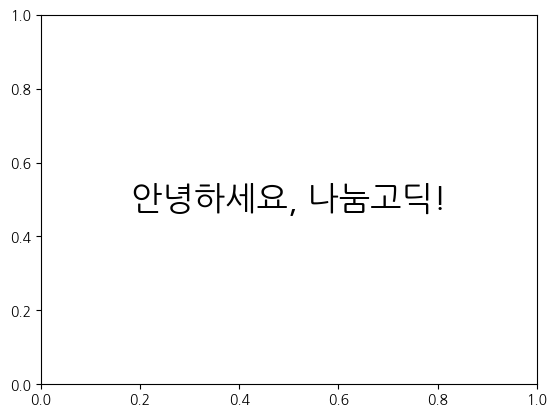

In [3]:

##########################################
### 한글이 깨지는 경우 아래 코드 실행하기 !!!###
##########################################
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트를 설치합니다.
!apt-get install -y fonts-nanum
!fc-cache -fv

# 설치된 나눔고딕 폰트를 matplotlib에 등록합니다.
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'

# 폰트가 잘 설정되었는지 테스트합니다.
plt.text(0.5, 0.5, '안녕하세요, 나눔고딕!', ha='center', va='center', size=24)
plt.show()

In [4]:
# 컬럼 모두 출력
pd.set_option('display.max_columns', None)

In [5]:
# 현재 작업 디렉토리 출력
wd = os.getcwd()
wd

'/home/sprintda07/project4/final_project_team3'

In [6]:
# 절대 경로 (수정해서 사용)
JSON_KEY_PATH = "key/my-projectcodeit.json"

In [7]:
# DuckDB 연결
env_path = dotenv.find_dotenv()

dotenv.load_dotenv(
    dotenv_path=env_path,
    override=True
)

mem_con = dd.connect("mydb.duckdb")

HMAC_ID = os.getenv("HMAC_ID")
HMAC_PW = os.getenv("HMAC_PW")

secret_gcs = f"""
CREATE SECRET (
    TYPE GCS,
    KEY_ID '{HMAC_ID}',
    SECRET '{HMAC_PW}'
);
"""

mem_con.execute(secret_gcs)
mem_con.execute("FROM duckdb_secrets()").df()

,name,type,provider,persistent,storage,scope,secret_string
0,__default_gcs,gcs,config,False,memory,"[gcs://, gs://]",name=__default_gcs;type=gcs;provider=config;se...


### 데이터 불러오기

In [9]:
attendance_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_attendance.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
blockrecord_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_blockrecord.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
failpaymenthistory_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_failpaymenthistory.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
friendrequest_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_friendrequest.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
group_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_group.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
nearbyschool_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_nearbyschool.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
paymenthistory_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
pointhistory_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
school_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_school.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
timelinereport_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_timelinereport.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
contacts_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_user_contacts.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
userquestionrecord_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
userwithdraw_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userwithdraw.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
event_receipts_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_receipts.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
events_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/events.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
user_df = pd.read_parquet(
                            "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_user.parquet",
                            engine='pyarrow',
                            storage_options={'token' : JSON_KEY_PATH}
                        )

In [ ]:
polls_question_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_question.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [ ]:
polls_questionpiece_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionpiece.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [ ]:
polls_questionreport_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionreport.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [ ]:
polls_questionset_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_questionset.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

In [ ]:
polls_usercandidate_df = pd.read_parquet(
                                      "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/polls_usercandidate.parquet",
                                      engine='pyarrow',
                                      storage_options={'token' : JSON_KEY_PATH}
                                  )

# 2. 피쳐 엔지니어링

### 1) 투표 테이블: 투표기록 + 포인트 기록
userquestionrecord_df

In [11]:
import gcsfs, duckdb
fs = gcsfs.GCSFileSystem(token=JSON_KEY_PATH) 
con = duckdb.connect("mydb.duckdb")
con.register_filesystem(fs)

In [21]:
userquestionrecord_df = mem_con.execute("""
    SELECT * FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_userquestionrecord.parquet')
""").fetchdf()

print(userquestionrecord_df.head())
pointhistory_df = mem_con.execute("""
    SELECT * FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_pointhistory.parquet')
""").fetchdf()

print(pointhistory_df.head())

       id status          created_at  chosen_user_id  question_id  user_id  \
0  771777      C 2023-04-28 12:27:49          849469          252   849436   
1  771800      C 2023-04-28 12:28:02          849446          244   849436   
2  771812      C 2023-04-28 12:28:09          849454          183   849436   
3  771828      C 2023-04-28 12:28:16          847375          101   849436   
4  771851      C 2023-04-28 12:28:26          849477          209   849436   

   question_piece_id  has_read answer_status   answer_updated_at  \
0             998458         0             N 2023-04-28 12:27:49   
1             998459         0             N 2023-04-28 12:28:02   
2             998460         1             N 2023-04-28 12:28:09   
3             998461         0             N 2023-04-28 12:28:16   
4             998462         1             N 2023-04-28 12:28:26   

   report_count  opened_times  
0             0             0  
1             0             0  
2             0           

In [22]:
len(userquestionrecord_df), len(pointhistory_df)

(1217558, 2338918)

In [23]:
pointhistory_df = pointhistory_df.sort_values("created_at")
userquestionrecord_df = userquestionrecord_df.sort_values("created_at")

In [24]:
# pointhistory_df를 user_id와 user_question_record_id로 그룹화하여, delta_point를 리스트화
updated_pointhistory_df = (
    pointhistory_df.groupby(["user_question_record_id", "user_id"])["delta_point"]
    .apply(list)
    .reset_index()
    .rename(columns={"user_id": "point_owner", "delta_point": "delta_points"})
)
updated_pointhistory_df

,user_question_record_id,point_owner,delta_points
0,771777.0,849436,[9]
1,771800.0,849436,[9]
2,771812.0,849436,[5]
3,771828.0,849436,[13]
4,771851.0,849436,[5]
...,...,...,...
2227067,161666462.0,855525,[14]
2227068,161666463.0,855525,[11]
2227069,161666463.0,855526,[11]
2227070,161666464.0,855525,[12]


In [25]:
# join on user_id
merged_case1 = userquestionrecord_df.merge(
    updated_pointhistory_df,
    left_on=["id", "user_id"],
    right_on=["user_question_record_id", "point_owner"],
)

In [26]:
# join on chosen_user_id
merged_case2 = userquestionrecord_df.merge(
    updated_pointhistory_df,
    left_on=["id", "chosen_user_id"],
    right_on=["user_question_record_id", "point_owner"],
)

In [27]:
# 최종 데이터프레임 생성
df_merged = pd.concat([merged_case1, merged_case2], axis=0)
df_merged

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,user_question_record_id,point_owner,delta_points
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,771777.0,849436,[9]
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,771800.0,849436,[9]
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,771812.0,849436,[5]
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,771828.0,849436,[13]
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,771851.0,849436,[5]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011472,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,161666166.0,945560,[8]
1011473,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,161666461.0,850774,[5]
1011474,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,161666462.0,855509,[14]
1011475,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,161666463.0,855526,[11]


In [103]:
df_merged.iloc[0]

id                                      771777
status                                       C
created_at                 2023-04-28 12:27:49
chosen_user_id                          849469
question_id                                252
user_id                                 849436
question_piece_id                       998458
has_read                                     0
answer_status                                N
answer_updated_at          2023-04-28 12:27:49
report_count                                 0
opened_times                                 0
user_question_record_id               771777.0
point_owner                             849436
delta_points                               [9]
Name: 0, dtype: object

In [100]:
# DuckDB에 데이터프레임 저장
mem_con.execute("""
    COPY df_merged TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet' (FORMAT PARQUET);
""")

In [ ]:
# pandas로 GCS에 데이터 저장
# def write_data_to_gcs(df, JSON_KEY_PATH, DATASET_PATH, file_name):
#     df.to_parquet(
#         path=f'{DATASET_PATH}/{file_name}.parquet',
#         engine='pyarrow',
#         compression='gzip',
#         index=False,
#         storage_options={'token' : JSON_KEY_PATH}
#     )
# write_data_to_gcs(df_merged, JSON_KEY_PATH, "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes", "vote_point_df")

# 3. 추가 EDA

In [8]:
question_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/question_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [9]:
vote_point_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/vote_point_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [10]:
event_info_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/event_info_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [11]:
user_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/user_df.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

In [12]:
paymenthistory_df = pd.read_parquet(
    "gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/accounts_paymenthistory.parquet",
    engine='pyarrow',
    storage_options={'token' : JSON_KEY_PATH}
)

question_df

1. 어떤 질문에 투표/스킵이 가장 많은가?

In [13]:
question_stats = (
    question_df
    .groupby("question_text")
    .agg(
        vote_count=("is_voted", "sum"),
        skip_count=("is_skipped", "sum"),
        total_count=("is_voted", "count")
    )
    .reset_index()
)
print("=== 질문별 투표통계 (Top 10) ===")
print(question_stats.sort_values("vote_count", ascending=False).head(10))


print("\n\n=== 질문별 스킵통계 (Top 10) ===")
print(question_stats.sort_values("skip_count", ascending=False).head(10))

=== 질문별 투표통계 (Top 10) ===
                      question_text  vote_count  skip_count  total_count
87                             vote      9703.0         9.0        10169
26             2세가 가장 귀여울 것 같은 사람은?      2174.0         3.0         2228
500                 같이 캠핑가고 싶은 사람은?      2123.0         1.0         2169
1256              라면 잘 끓일 것 같은 사람은?      2115.0         1.0         2157
3270  처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?      1998.0         2.0         2030
1464          모든 사람과 잘 지낼 것 같은 사람은?      1987.0         1.0         2021
3358       축제에서 공연을 제일 잘 할거 같은 사람은?      1985.0         1.0         2017
2297    앞으로의 인생을 가장 재미있게 살것 같은 사람은?      1975.0         1.0         2009
1612         반려동물과 가장 잘 지낼거 같은 사람은?      1958.0         2.0         1985
129                가장 깔끔할 것 같은 친구는?      1957.0         1.0         1998


=== 질문별 스킵통계 (Top 10) ===
                      question_text  vote_count  skip_count  total_count
87                             vote      9703.0         9.0        101

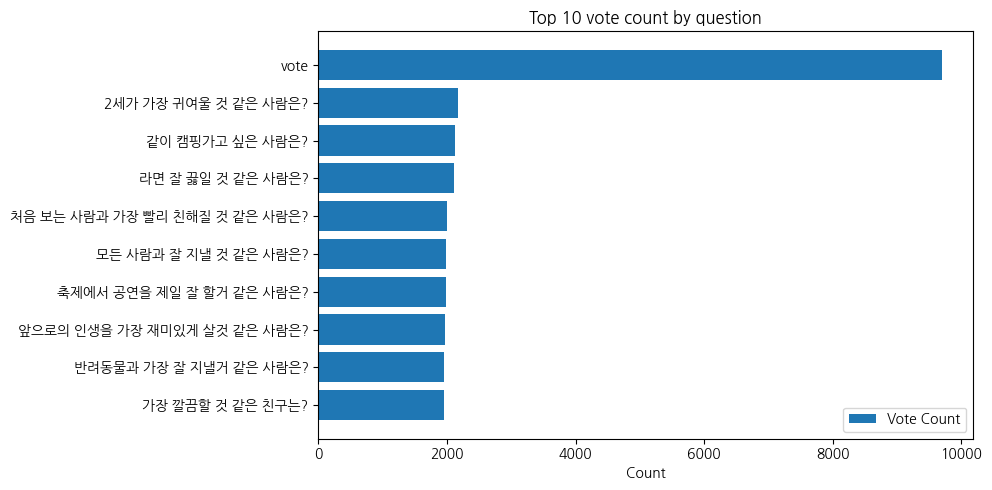

In [14]:
plt.figure(figsize=(10, 5))
_question_stats = question_stats.sort_values("vote_count", ascending=False).head(10)
plt.barh(_question_stats["question_text"], _question_stats["vote_count"], label="Vote Count")
plt.title("Top 10 vote count by question")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

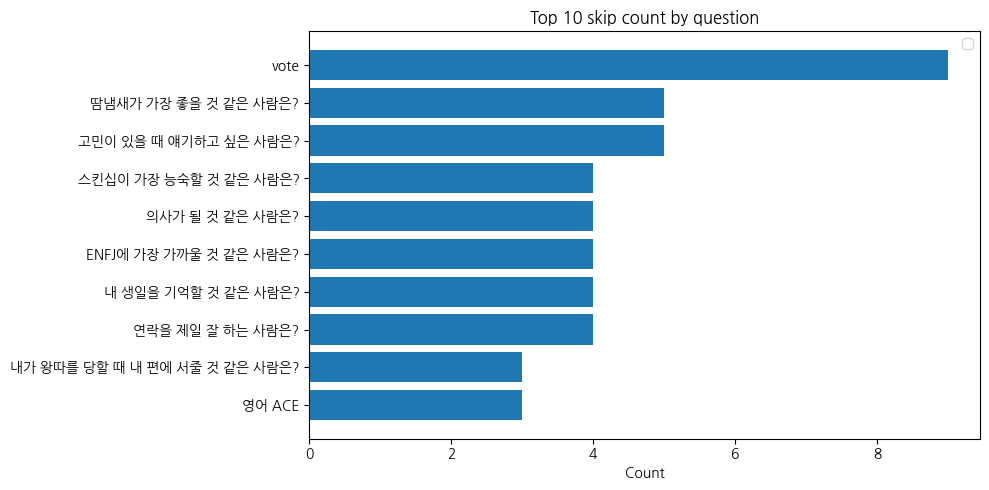

In [15]:
plt.figure(figsize=(10, 5))
_question_stats = question_stats.sort_values("skip_count", ascending=False).head(10)
plt.barh(_question_stats["question_text"], _question_stats["skip_count"])
plt.title("Top 10 skip count by question")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. 어느 유저가 투표/스킵이 가장 많은가?

In [16]:
user_stats = (
    question_df
    .groupby("user_id")
    .agg(
        vote_count=("is_voted", "sum"),
        skip_count=("is_skipped", "sum"),
        total_count=("is_voted", "count")
    )
    
    .reset_index()
)
print("=== 유저별 투표 통계 (Top 10) ===")
print(user_stats.sort_values("vote_count", ascending=False).head(10))


print("\\n\n=== 유저별 스킵 통계 (Top 10) ===")
print(user_stats.sort_values("skip_count", ascending=False).head(10))

=== 유저별 투표 통계 (Top 10) ===
      user_id  vote_count  skip_count  total_count
20     849103      2786.0         0.0         2796
808    876509      1708.0         0.0         1718
277    856042      1701.0         0.0         1711
3312  1213990      1695.0         0.0         1705
2879  1159163      1656.0         0.0         1666
2227  1058255      1544.0         0.0         1554
3231  1206529      1544.0         0.0         1554
1865   952220      1527.0         0.0         1537
2984  1170559      1513.0         0.0         1523
3469  1236004      1482.0         0.0         1492
\n
=== 유저별 스킵 통계 (Top 10) ===
      user_id  vote_count  skip_count  total_count
3819  1289797        10.0         9.0           10
2643  1138345       261.0         9.0          262
3292  1211694        10.0         9.0           10
1463   888374       207.0         9.0          208
1797   931987       135.0         9.0          136
4178  1381024        22.0         8.0           24
3958  1325806         8.0

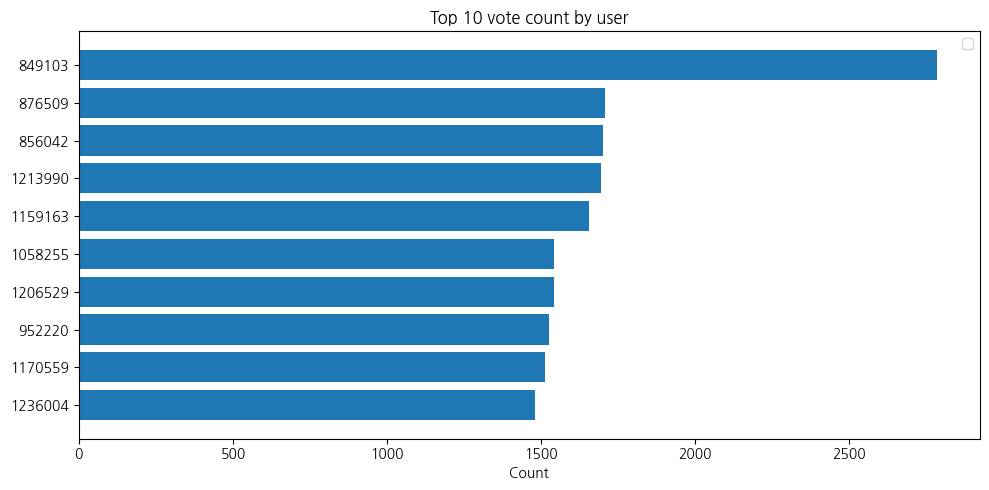

In [17]:
plt.figure(figsize=(10, 5))
_user_stats = user_stats.sort_values("vote_count", ascending=False).head(10)
vote_merged_df = user_df.merge(_user_stats, on="user_id", how="right")
_user_stats["user_id"] = _user_stats["user_id"].astype(str)
plt.barh(_user_stats["user_id"], _user_stats["vote_count"])
plt.title("Top 10 vote count by user")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

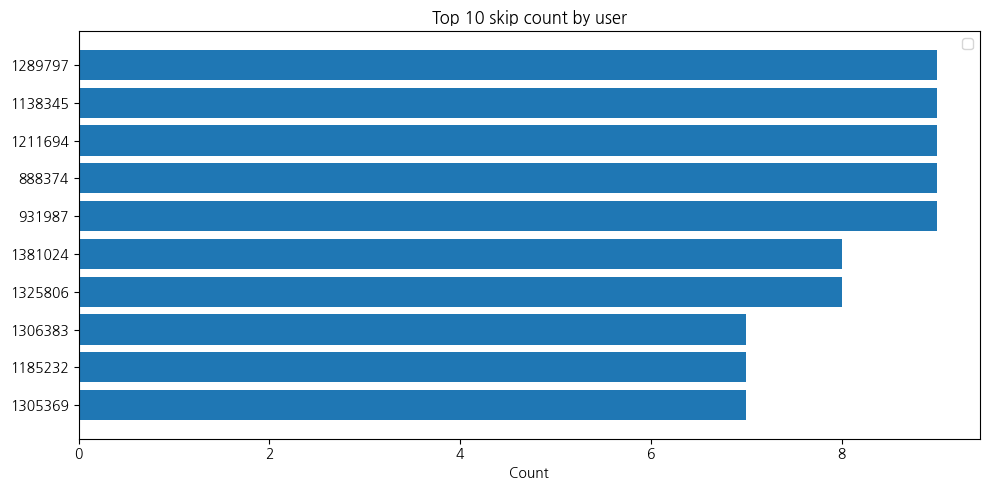

In [18]:
plt.figure(figsize=(10, 5))
_user_stats = user_stats.sort_values("skip_count", ascending=False).head(10)
skip_merged_df = user_df.merge(_user_stats, on="user_id", how="right")
_user_stats["user_id"] = _user_stats["user_id"].astype(str)
plt.barh(_user_stats["user_id"], _user_stats["skip_count"])
plt.title("Top 10 skip count by user")
plt.xlabel("Count")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
vote_merged_df.gender.value_counts()

gender
F    7
M    3
Name: count, dtype: int64

In [20]:
vote_merged_df.school_type.value_counts()

school_type
H    8
M    2
Name: count, dtype: int64

In [21]:
vote_merged_df["attendance_date_list"] = vote_merged_df["attendance_date_list"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

vote_merged_df["n_attendance_dates"] = vote_merged_df["attendance_date_list"].apply(lambda x: len(x))
vote_merged_df["n_attendance_dates"].describe()

count    10.000000
mean     18.100000
std      20.534253
min       0.000000
25%       5.000000
50%      11.000000
75%      25.000000
max      69.000000
Name: n_attendance_dates, dtype: float64

In [22]:
vote_merged_df["friend_id_list"] = vote_merged_df["friend_id_list"].apply(json.loads)
vote_merged_df["n_friends"] = vote_merged_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
vote_merged_df

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,vote_count,skip_count,total_count,n_attendance_dates,n_friends
0,849103,0,0,F,41607,"[857602, 857603, 858120, 860682, 839179, 84840...",0,2023-04-27 13:45:23.532923,[],[],N,0,0,3,0,3833.0,99303.0,"[2023-05-28, 2023-05-29, 2023-05-30, 2023-05-3...",1.0,2.0,271.0,충청남도 천안시 서북구,491.0,H,2786.0,0.0,2796,69,128
1,876509,0,0,F,1376,"[886913, 879875, 871940, 875780, 884230, 88320...",1,2023-05-03 13:09:50.190280,[],[875705],N,0,0,0,0,10153.0,331598.0,"[2023-06-18, 2023-06-19, 2023-06-20, 2023-06-2...",2.0,13.0,4516.0,경기도 화성시,507.0,H,1708.0,0.0,1718,29,60
2,856042,0,0,F,5887,"[864897, 855694, 874002, 861205, 863392, 86595...",1,2023-04-29 23:52:14.010394,[],[],N,0,2,4,35,3833.0,125871.0,"[2023-05-28, 2023-05-29, 2023-05-30, 2023-06-0...",1.0,2.0,271.0,충청남도 천안시 서북구,491.0,H,1701.0,0.0,1711,5,51
3,1213990,0,0,M,3883,"[1185408, 1206529, 1220102, 1217035, 1206668, ...",1,2023-05-13 11:25:06.724268,[],[],N,0,0,0,12,33879.0,25001.0,"[2023-05-27, 2023-05-28, 2023-05-29, 2023-05-3...",1.0,10.0,1719.0,울산광역시 울주군,550.0,H,1695.0,0.0,1705,9,29
4,1159163,0,0,F,11021,"[1217921, 1158530, 1241988, 1122820, 1142661, ...",1,2023-05-12 05:51:30.378418,[],[],N,0,1,0,2,45939.0,152020.0,"[2023-05-29, 2023-05-30, 2023-05-31, 2023-06-0...",2.0,12.0,5491.0,경기도 광주시,486.0,H,1656.0,0.0,1666,13,63
5,1058255,0,0,F,15723,"[1432576, 1159808, 1242882, 1138054, 1448327, ...",1,2023-05-09 14:15:04.082002,[],[],N,0,2,0,3,36400.0,NaN,[],2.0,9.0,5520.0,경기도 광명시,500.0,M,1544.0,0.0,1554,0,75
6,1206529,0,0,F,2847,"[955521, 1204866, 1220102, 1217163, 1206668, 1...",1,2023-05-13 09:04:54.133308,[],[],N,0,1,0,77,33879.0,213862.0,"[2023-05-29, 2023-05-30, 2023-06-01, 2023-06-0...",1.0,10.0,1719.0,울산광역시 울주군,550.0,H,1544.0,0.0,1554,5,52
7,952220,0,0,M,21998,"[886787, 886180, 886245, 888453, 905351, 89616...",1,2023-05-07 08:21:12.387888,[],[],N,0,0,0,0,6875.0,9702.0,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",1.0,8.0,352.0,충청남도 아산시,491.0,H,1527.0,0.0,1537,26,14
8,1170559,0,0,M,11908,"[1161604, 959620, 1159697, 1210259, 1100179, 9...",1,2023-05-12 11:03:39.049790,[],[],N,0,0,0,0,27495.0,39253.0,"[2023-05-27, 2023-05-29, 2023-05-30, 2023-05-3...",3.0,10.0,1478.0,인천광역시 서구,489.0,M,1513.0,0.0,1523,22,28
9,1236004,0,0,F,7775,"[1227266, 1275523, 1257737, 1354890, 1256460, ...",1,2023-05-13 16:03:41.457384,[],[],N,0,0,0,3,55673.0,58450.0,"[2023-05-27, 2023-05-29, 2023-06-18]",2.0,6.0,1719.0,울산광역시 울주군,550.0,H,1482.0,0.0,1492,3,46


In [23]:
skip_merged_df.gender.value_counts()

gender
F    9
M    1
Name: count, dtype: int64

In [24]:
skip_merged_df.school_type.value_counts()

school_type
H    9
M    1
Name: count, dtype: int64

In [25]:
skip_merged_df["attendance_date_list"] = skip_merged_df["attendance_date_list"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)

skip_merged_df["n_attendance_dates"] = skip_merged_df["attendance_date_list"].apply(lambda x: len(x))
skip_merged_df["n_attendance_dates"].describe()

count    10.000000
mean      2.300000
std       6.929005
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      22.000000
Name: n_attendance_dates, dtype: float64

In [26]:
skip_merged_df["friend_id_list"] = skip_merged_df["friend_id_list"].apply(json.loads)
skip_merged_df["n_friends"] = skip_merged_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
skip_merged_df

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,vote_count,skip_count,total_count,n_attendance_dates,n_friends
0,1289797,0,0,F,903,"[927882, 1001610, 1077653, 923933, 913959, 924...",1,2023-05-15 11:51:29.487137,[],[],N,0,1,0,28,17950.0,NaN,[],2.0,2.0,1478.0,인천광역시 서구,489.0,M,10.0,9.0,10,0,50
1,1138345,0,0,F,6923,"[1308691, 1154585, 1274398, 1165346, 1147938, ...",1,2023-05-11 13:53:05.181784,[],[],N,0,1,0,335,46796.0,74241.0,[2023-05-28],2.0,2.0,5491.0,경기도 광주시,486.0,H,261.0,9.0,262,1,82
2,1211694,0,0,M,5620,"[1217928, 1210507, 1214735, 1207322, 1205405, ...",0,2023-05-13 10:49:21.077194,[],[1208640],N,0,1,0,221,44628.0,NaN,[],1.0,4.0,1719.0,울산광역시 울주군,550.0,H,10.0,9.0,10,0,61
3,888374,0,0,F,2468,"[885000, 860304, 888212, 888597, 881301, 88631...",1,2023-05-05 14:40:08.902152,[],[],N,0,1,0,48,12277.0,NaN,[],1.0,13.0,352.0,충청남도 아산시,491.0,H,207.0,9.0,208,0,27
4,931987,0,0,F,4574,"[886274, 887299, 883202, 883737, 849436, 88477...",1,2023-05-06 22:59:43.421026,[],[],N,0,1,0,196,12015.0,NaN,[],2.0,3.0,352.0,충청남도 아산시,491.0,H,135.0,9.0,136,0,78
5,1381024,0,0,F,68,"[968590, 1131675, 1144475, 1161757, 1277854, 1...",0,2023-05-19 07:35:44.413861,[],[],N,0,1,0,4,24762.0,NaN,[],1.0,12.0,5372.0,경기도 남양주시,505.0,H,22.0,8.0,24,0,37
6,1325806,0,0,F,254,"[1269125, 1165894, 1104234, 1091211, 1097932, ...",1,2023-05-16 12:48:41.722364,[],[],N,0,1,0,37,42042.0,NaN,[],2.0,6.0,5372.0,경기도 남양주시,505.0,H,8.0,8.0,10,0,37
7,1306383,0,0,F,2686,"[1117193, 1052425, 860173, 891669, 1368725, 12...",1,2023-05-16 04:05:33.541755,[],[],N,0,0,0,0,11104.0,99535.0,"[2023-05-28, 2023-05-29, 2023-05-30, 2023-05-3...",1.0,12.0,5491.0,경기도 광주시,486.0,H,212.0,7.0,214,22,29
8,1185232,0,0,F,1426,"[1187589, 1205269, 1202464, 1199401, 1183660, ...",0,2023-05-12 15:05:57.057229,[],"[1160250, 1198505, 1201680]",N,0,1,0,1,50815.0,NaN,[],3.0,2.0,5491.0,경기도 광주시,486.0,H,316.0,7.0,319,0,29
9,1305369,0,0,F,2606,"[1298438, 1354890, 1238029, 973584, 1277972, 1...",1,2023-05-16 03:22:04.118364,[],[],N,0,1,0,171,55673.0,NaN,[],2.0,6.0,1719.0,울산광역시 울주군,550.0,H,100.0,7.0,102,0,33


In [27]:
skip_merged_df["vote_count"].describe()

count     10.000000
mean     128.100000
std      115.780875
min        8.000000
25%       13.000000
50%      117.500000
75%      210.750000
max      316.000000
Name: vote_count, dtype: float64

3. 어느 시간대에 투표가 가장 활발한가?

In [28]:
question_df["hour"] = pd.to_datetime(question_df["created_at_set"]).dt.hour

time_stats = (
    question_df
    .groupby("hour")
    .agg(
        vote_count=("is_voted", "sum"),
        skip_count=("is_skipped", "sum"),
        total_count=("is_voted", "count")
    )
    .reset_index()
    
)
print("=== 시간대별 투표 통계 ===")
print(time_stats.sort_values("vote_count", ascending=False).head(10))

print("\n\n=== 시간대별 스킵 통계 ===")
print(time_stats.sort_values("skip_count", ascending=False).head(10))

=== 시간대별 투표 통계 ===
    hour  vote_count  skip_count  total_count
13    13    100194.0       122.0       104844
14    14     98339.0        86.0       102441
12    12     87884.0       111.0        91306
15    15     80773.0       113.0        84721
11    11     79125.0        93.0        82194
10    10     72312.0        64.0        74887
9      9     71597.0        54.0        74497
8      8     71463.0        74.0        74138
7      7     62424.0        45.0        64497
6      6     54960.0        48.0        57001


=== 시간대별 스킵 통계 ===
    hour  vote_count  skip_count  total_count
13    13    100194.0       122.0       104844
15    15     80773.0       113.0        84721
12    12     87884.0       111.0        91306
11    11     79125.0        93.0        82194
14    14     98339.0        86.0       102441
8      8     71463.0        74.0        74138
10    10     72312.0        64.0        74887
9      9     71597.0        54.0        74497
6      6     54960.0        48.0        

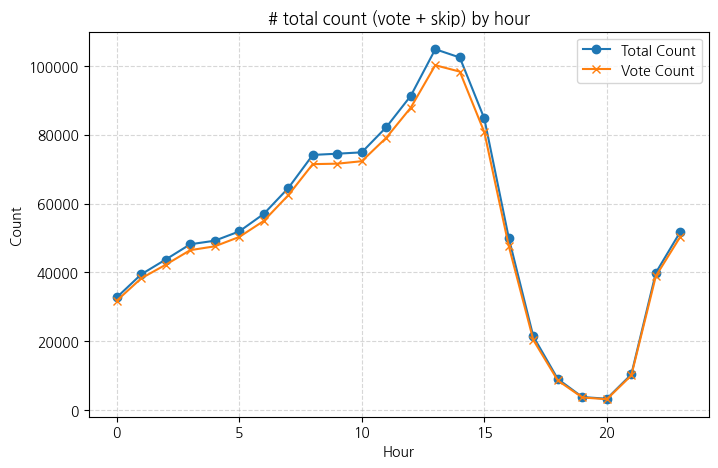

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(time_stats["hour"], time_stats["total_count"], marker="o", label="Total Count")
plt.plot(time_stats["hour"], time_stats["vote_count"], marker="x", label="Vote Count")
plt.title("# total count (vote + skip) by hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

vote_point_df

In [138]:
vote_point_df["n_delta_points"] = vote_point_df["delta_points"].apply(lambda x: len(x))
# 포인트 사용 -> negative points
vote_point_df["n_negative_points"] = vote_point_df["delta_points"].apply(lambda x: sum(1 for point in x if point < 0))
vote_point_df["sum_negative_points"] = vote_point_df["delta_points"].apply(lambda x: sum(point for point in x if point < 0))
# 포인트 지급 -> positive points
vote_point_df["n_positive_points"] = vote_point_df["delta_points"].apply(lambda x: sum(1 for point in x if point >= 0))
vote_point_df["sum_positive_points"] = vote_point_df["delta_points"].apply(lambda x: sum(point for point in x if point >= 0))

1. 어떤 질문에 포인트 사용 횟수가 많은가?

Top 10 포인트 사용 질문
     question_id  total_point
158          257          393
119          218          386
241          340          327
35           134          302
37           136          301
164          263          280
33           132          276
8            107          275
327          426          270
215          314          262


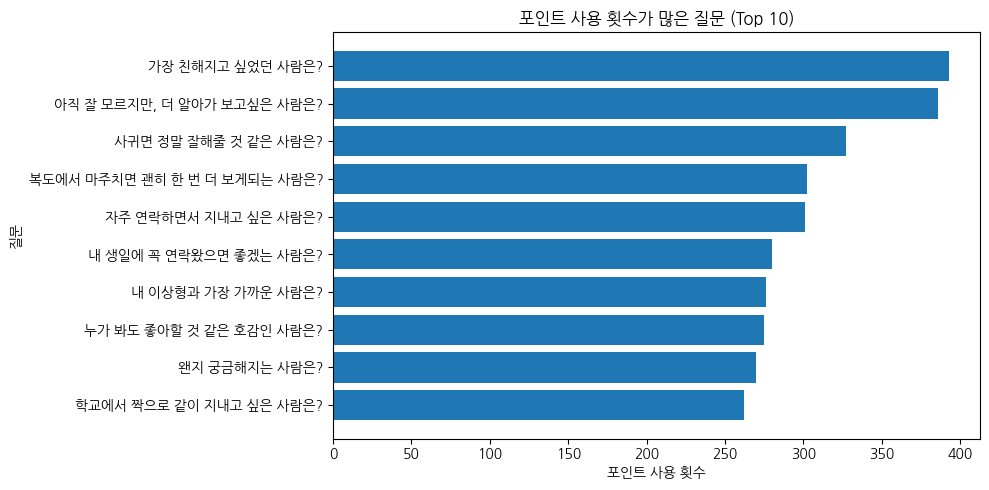

In [146]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(total_point=("n_negative_points", "sum"))
    .sort_values("total_point", ascending=False)
).head(10)
print("Top 10 포인트 사용 질문")
print(question_point_usage)

merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["total_point"])
plt.title("포인트 사용 횟수가 많은 질문 (Top 10)")
plt.ylabel("질문")
plt.xlabel("포인트 사용 횟수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. 어떤 질문에 포인트 지급 횟수가 많은가

Top 10 포인트 지급 질문
     question_id  total_point
71           170         3490
70           169         3481
112          211         3477
211          310         3474
87           186         3465
3            102         3441
191          290         3435
53           152         3415
145          244         3412
210          309         3393


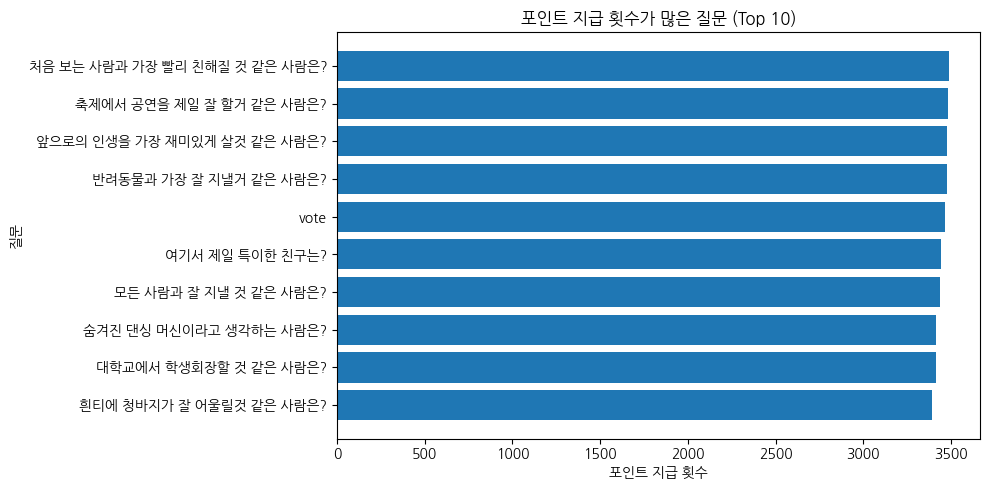

In [145]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(total_point=("n_positive_points", "sum"))
    .sort_values("total_point", ascending=False)
).head(10)
print("Top 10 포인트 지급 질문")
print(question_point_usage)

merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["total_point"])
plt.title("포인트 지급 횟수가 많은 질문 (Top 10)")
plt.ylabel("질문")
plt.xlabel("포인트 지급 횟수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

3. 어떤 질문에 포인트 사용 점수가 높은가

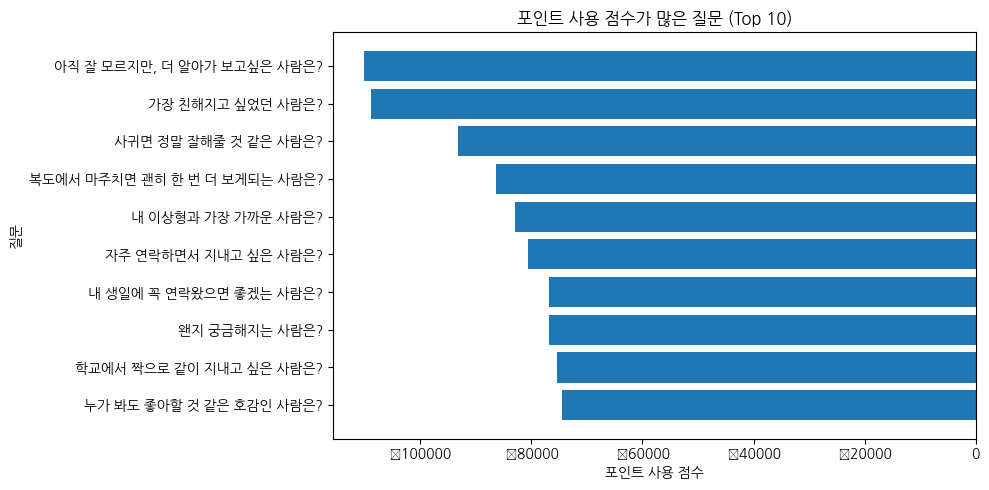

In [143]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(total_point=("sum_negative_points", "sum"))
    .sort_values("total_point", ascending=False)
).tail(10)
print("Top 10 포인트 사용 질문")
print(question_point_usage)

merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["total_point"])
plt.title("포인트 사용 점수가 많은 질문 (Top 10)")
plt.ylabel("질문")
plt.xlabel("포인트 사용 점수")
plt.tight_layout()
plt.show()

4. 어떤 질문에 유저 참여가 많았나?

Top 10 유저 참여 질문
     question_id  user_count
191          290        1454
145          244        1437
211          310        1424
112          211        1423
71           170        1422
70           169        1419
87           186        1419
90           189        1418
69           168        1415
210          309        1412


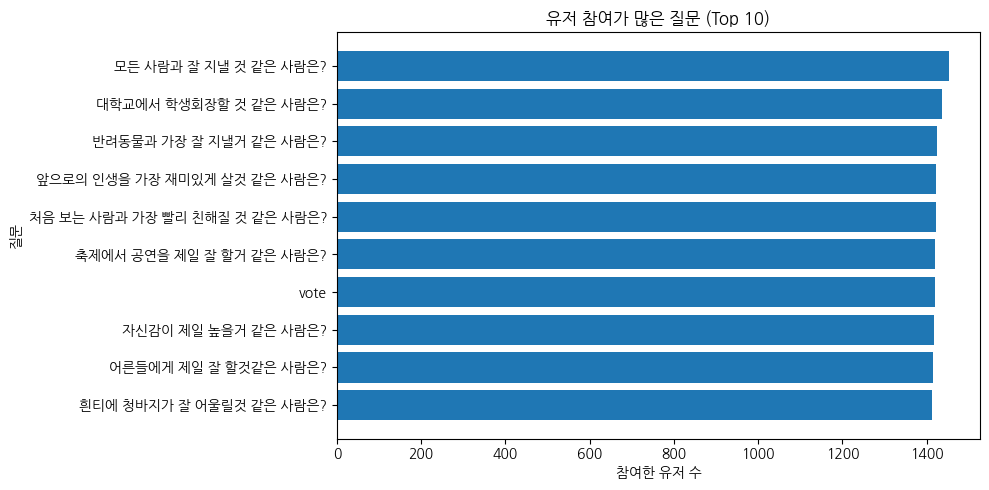

In [150]:
question_point_usage = (
    vote_point_df
    .groupby("question_id", as_index=False)
    .agg(user_count=("user_id", "nunique"))
    .sort_values("user_count", ascending=False)
).head(10)
print("Top 10 유저 참여 질문")
print(question_point_usage)

merged_df = question_df.merge(question_point_usage, on="question_id", how="right")

plt.figure(figsize=(10, 5))
plt.barh(merged_df["question_text"], merged_df["user_count"])
plt.title("유저 참여가 많은 질문 (Top 10)")
plt.ylabel("질문")
plt.xlabel("참여한 유저 수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

5. 어떤 유저가 선택을 많이 받는가?

In [163]:
user_selected = (
    vote_point_df
    .groupby(["chosen_user_id", "point_owner"], as_index=False)
    .size()
    .rename(columns={"size": "chosen_count"})
    .sort_values("chosen_count", ascending=False)
)
print("Top 10 선택 많이 받은 유저")
print(user_selected.head(10))

Top 10 선택 많이 받은 유저
        chosen_user_id  point_owner  chosen_count
64619           913265       913265          1239
126544         1206668      1206668          1054
163057         1402487      1402487          1052
100713         1122686      1122686          1042
77088           994573       994573           997
81239          1017281      1017281           997
103136         1132932      1132932           993
21975           873259       873259           971
127698         1207784      1207784           948
81307          1017447      1017447           917


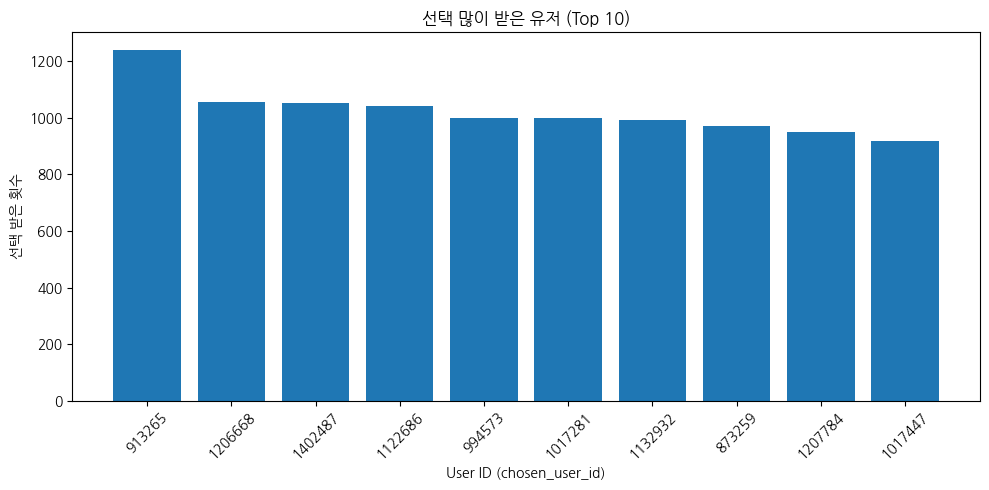

In [164]:
plt.figure(figsize=(10, 5))
plt.bar(user_selected["chosen_user_id"].astype(str).head(10),
        user_selected["chosen_count"].head(10))
plt.title("선택 많이 받은 유저 (Top 10)")
plt.xlabel("User ID (chosen_user_id)")
plt.ylabel("선택 받은 횟수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
merged_df = user_selected.head(10).merge(user_df, left_on="chosen_user_id", right_on="user_id", how="left")
merged_df

,chosen_user_id,chosen_count,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type
0,913265,1239,913265,0,0,M,5257,"[925184, 1103885, 1110033, 1036306, 946196, 15...",1,2023-05-06 12:47:33.544102,[],[],N,0,1,0,1258,17929.0,51551.0,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",2.0,11.0,1478.0,인천광역시 서구,489.0,M
1,1206668,1054,1206668,0,0,M,1240,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",1,2023-05-13 09:08:04.416313,[1209696],"[1210417, 1211694, 1187305, 1288492]",N,0,1,0,775,33879.0,NaN,None,1.0,10.0,1719.0,울산광역시 울주군,550.0,H
2,1402487,1049,1402487,0,0,M,3481,"[1402371, 1419804, 1403421, 1402919, 1406521, ...",1,2023-05-20 11:49:26.073098,[],[],N,0,0,0,893,68957.0,91963.0,"[""2023-05-28"", ""2023-05-29"", ""2023-05-30""]",3.0,4.0,4426.0,경상남도 거제시,483.0,H
3,1122686,1042,1122686,0,0,M,5427,"[1432576, 1133058, 1205259, 1089040, 1043473, ...",1,2023-05-11 08:08:47.657849,[],[],N,0,1,0,999,29558.0,NaN,None,2.0,10.0,5520.0,경기도 광명시,500.0,M
4,994573,997,994573,0,0,F,177,"[1432576, 1189890, 1427466, 964107, 1205259, 9...",0,2023-05-08 07:11:58.076137,[],[],N,0,0,0,885,31383.0,NaN,None,2.0,4.0,5520.0,경기도 광명시,500.0,M
5,1017281,997,1017281,0,0,F,3570,"[1038861, 943631, 1172496, 1224723, 1018394, 1...",0,2023-05-08 14:20:46.163313,[],[],N,0,1,0,1004,22968.0,NaN,None,3.0,7.0,5520.0,경기도 광명시,500.0,M
6,1132932,993,1132932,0,0,F,2916,"[1134602, 1205259, 1043473, 1430036, 1044507, ...",1,2023-05-11 12:39:39.339638,[],[],N,0,1,0,957,23119.0,NaN,None,2.0,12.0,5520.0,경기도 광명시,500.0,M
7,873259,971,873259,0,0,F,2177,"[871940, 941573, 876549, 884230, 883208, 87757...",0,2023-05-02 23:29:42.843284,[],[],N,0,1,0,943,9505.0,NaN,None,2.0,4.0,4516.0,경기도 화성시,507.0,H
8,1207784,948,1207784,0,0,M,882,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",0,2023-05-13 09:35:18.591577,[],[1180034],N,4,1,0,709,49478.0,NaN,None,1.0,2.0,1719.0,울산광역시 울주군,550.0,H
9,1017447,917,1017447,0,0,F,1707,"[947719, 1039882, 943631, 1172496, 1036834, 10...",1,2023-05-08 14:22:41.181466,[],[],N,0,0,0,5,34259.0,333074.0,"[""2023-06-22"", ""2023-08-02""]",3.0,12.0,5520.0,경기도 광명시,500.0,M


In [59]:
merged_df.gender.value_counts()

gender
M    5
F    5
Name: count, dtype: int64

In [60]:
merged_df.school_type.value_counts()

school_type
M    6
H    4
Name: count, dtype: int64

In [61]:
merged_df["friend_id_list"] = merged_df["friend_id_list"].apply(json.loads)
merged_df["n_friends"] = merged_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
merged_df

,chosen_user_id,chosen_count,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type,n_friends
0,913265,1239,913265,0,0,M,5257,"[925184, 1103885, 1110033, 1036306, 946196, 15...",1,2023-05-06 12:47:33.544102,[],[],N,0,1,0,1258,17929.0,51551.0,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",2.0,11.0,1478.0,인천광역시 서구,489.0,M,205
1,1206668,1054,1206668,0,0,M,1240,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",1,2023-05-13 09:08:04.416313,[1209696],"[1210417, 1211694, 1187305, 1288492]",N,0,1,0,775,33879.0,NaN,None,1.0,10.0,1719.0,울산광역시 울주군,550.0,H,214
2,1402487,1049,1402487,0,0,M,3481,"[1402371, 1419804, 1403421, 1402919, 1406521, ...",1,2023-05-20 11:49:26.073098,[],[],N,0,0,0,893,68957.0,91963.0,"[""2023-05-28"", ""2023-05-29"", ""2023-05-30""]",3.0,4.0,4426.0,경상남도 거제시,483.0,H,94
3,1122686,1042,1122686,0,0,M,5427,"[1432576, 1133058, 1205259, 1089040, 1043473, ...",1,2023-05-11 08:08:47.657849,[],[],N,0,1,0,999,29558.0,NaN,None,2.0,10.0,5520.0,경기도 광명시,500.0,M,168
4,994573,997,994573,0,0,F,177,"[1432576, 1189890, 1427466, 964107, 1205259, 9...",0,2023-05-08 07:11:58.076137,[],[],N,0,0,0,885,31383.0,NaN,None,2.0,4.0,5520.0,경기도 광명시,500.0,M,192
5,1017281,997,1017281,0,0,F,3570,"[1038861, 943631, 1172496, 1224723, 1018394, 1...",0,2023-05-08 14:20:46.163313,[],[],N,0,1,0,1004,22968.0,NaN,None,3.0,7.0,5520.0,경기도 광명시,500.0,M,98
6,1132932,993,1132932,0,0,F,2916,"[1134602, 1205259, 1043473, 1430036, 1044507, ...",1,2023-05-11 12:39:39.339638,[],[],N,0,1,0,957,23119.0,NaN,None,2.0,12.0,5520.0,경기도 광명시,500.0,M,119
7,873259,971,873259,0,0,F,2177,"[871940, 941573, 876549, 884230, 883208, 87757...",0,2023-05-02 23:29:42.843284,[],[],N,0,1,0,943,9505.0,NaN,None,2.0,4.0,4516.0,경기도 화성시,507.0,H,149
8,1207784,948,1207784,0,0,M,882,"[1228800, 1209858, 1006085, 1220102, 1192968, ...",0,2023-05-13 09:35:18.591577,[],[1180034],N,4,1,0,709,49478.0,NaN,None,1.0,2.0,1719.0,울산광역시 울주군,550.0,H,179
9,1017447,917,1017447,0,0,F,1707,"[947719, 1039882, 943631, 1172496, 1036834, 10...",1,2023-05-08 14:22:41.181466,[],[],N,0,0,0,5,34259.0,333074.0,"[""2023-06-22"", ""2023-08-02""]",3.0,12.0,5520.0,경기도 광명시,500.0,M,101


3. 선택을 많이 받은 유저가 투표도 활발하게 하는가?

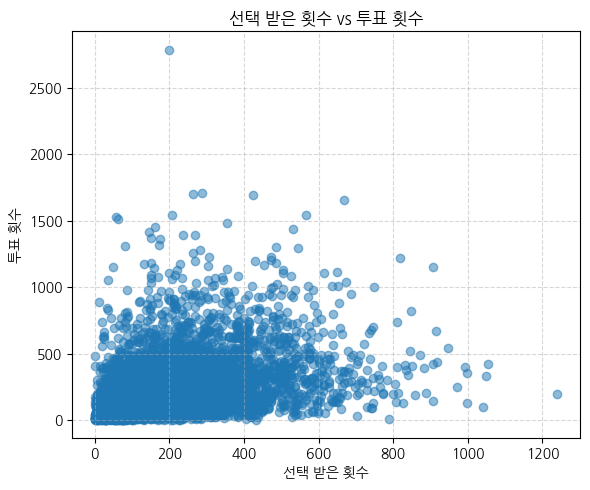

선택 받은 횟수와 투표 횟수 간 상관계수: 0.35


In [62]:
user_voting = (
    vote_point_df
    .groupby("user_id", as_index=False)
    .size()
    .rename(columns={"size": "vote_count"})
    .sort_values("vote_count", ascending=False)
)

merged_selection_vote = (
    user_selected.merge(user_voting,
                        left_on="chosen_user_id",
                        right_on="user_id",
                        how="inner")
)
plt.figure(figsize=(6, 5))
plt.scatter(merged_selection_vote["chosen_count"],
            merged_selection_vote["vote_count"],
            alpha=0.5)
plt.title("선택 받은 횟수 vs 투표 횟수")
plt.xlabel("선택 받은 횟수")
plt.ylabel("투표 횟수")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

correlation = merged_selection_vote[["chosen_count", "vote_count"]].corr().iloc[0, 1]
print(f"선택 받은 횟수와 투표 횟수 간 상관계수: {correlation:.2f}")

4. 어느 시간대에 포인트 사용량이 많은가?

시간대별 포인트 사용량
    hour  delta_point
23    23     536140.0
12    12     513951.0
13    13     513119.0
14    14     498552.0
11    11     460799.0
10    10     444140.0
8      8     440316.0
9      9     434286.0
7      7     404970.0
5      5     403923.0
6      6     386908.0
22    22     369699.0
15    15     366862.0
3      3     366318.0
4      4     349139.0
2      2     342544.0
1      1     328938.0
0      0     304632.0
16    16     264924.0
17    17     145175.0
21    21     103194.0
18    18      67233.0
20    20      30759.0
19    19      27896.0


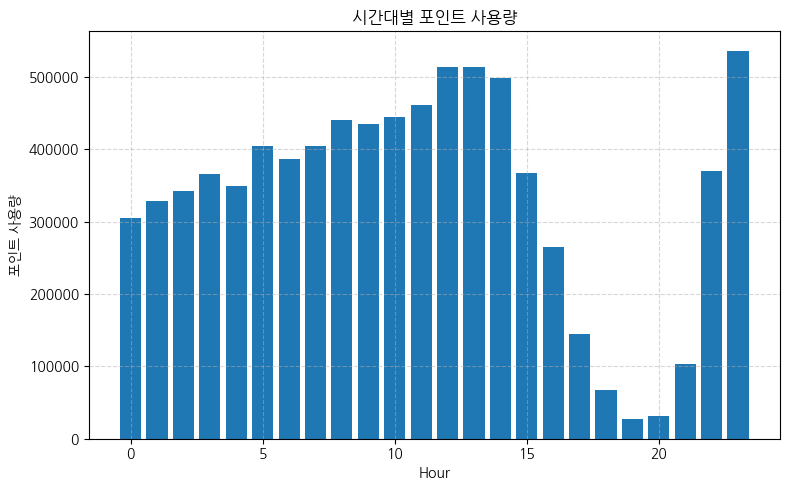

In [67]:
vote_point_df["hour"] = pd.to_datetime(vote_point_df["created_at_point"]).dt.hour
point_by_hour = (
    vote_point_df.groupby("hour", as_index=False)["delta_point"].sum()
    .sort_values("delta_point", ascending=False)
)
print("시간대별 포인트 사용량")
print(point_by_hour)

plt.figure(figsize=(8, 5))
plt.bar(point_by_hour["hour"], point_by_hour["delta_point"])
plt.title("시간대별 포인트 사용량")
plt.xlabel("Hour")
plt.ylabel("포인트 사용량")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

5. 유저 세그맨트

포인트 사용자 vs 미사용자 수
segment
point_user        3923
non_point_user     926
Name: count, dtype: int64


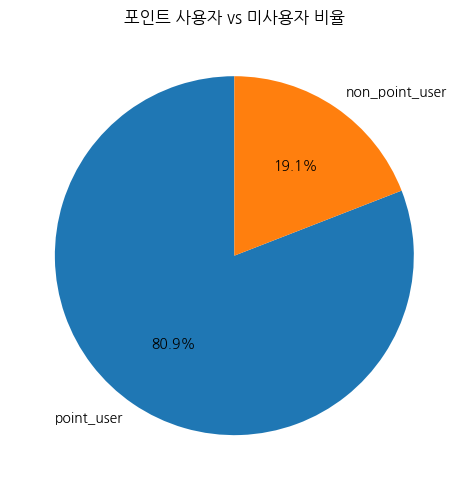

In [69]:
user_point_usage = (
    vote_point_df.groupby("user_id", as_index=False)["delta_point"].sum()
)
user_point_usage["segment"] = user_point_usage["delta_point"].apply(
    lambda x: "point_user" if x > 0 else "non_point_user"
)

segment_summary = user_point_usage["segment"].value_counts()
print("포인트 사용자 vs 미사용자 수")
print(segment_summary)

plt.figure(figsize=(5, 5))
plt.pie(segment_summary, labels=segment_summary.index, autopct="%1.1f%%",
        startangle=90)
plt.title("포인트 사용자 vs 미사용자 비율")
plt.tight_layout()
plt.show()

event_info_df

1. 어느 이벤트가 가장 많이 참여 되었는가

=== 이벤트별 참여 Top 10 ===
   event_id           title  plus_point_event  participation_count
0         1   코드잇 은행 가입 이벤트               500                  252
1         2  코드잇 멤버십 가입 이벤트              1000                   37
2         3   예고 영상 기대평 이벤트               500                   20


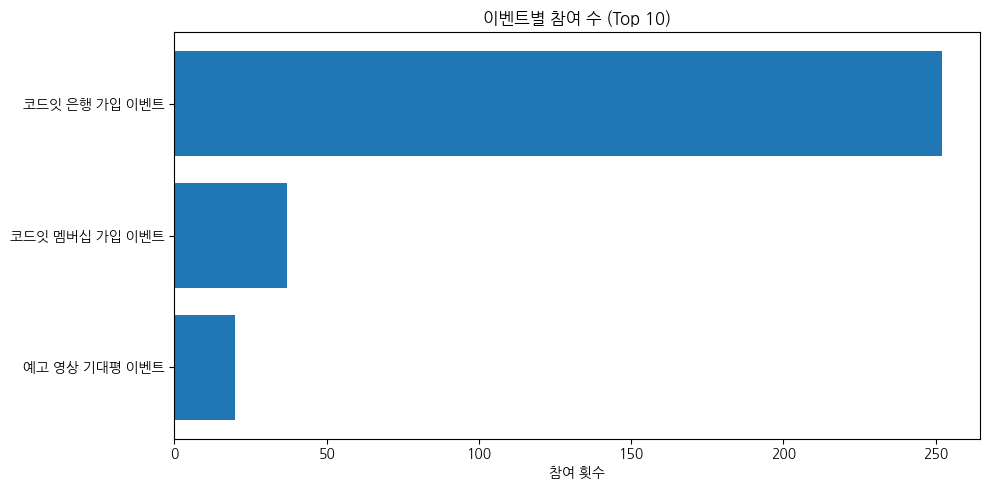

In [75]:
event_participation = (
    event_info_df
    .groupby(["event_id", "title", "plus_point_event"], as_index=False)
    .size()
    .rename(columns={"size": "participation_count"})
    .sort_values("participation_count", ascending=False)
)
print("=== 이벤트별 참여 Top 10 ===")
print(event_participation.head(10))

# 시각화
plt.figure(figsize=(10, 5))
plt.barh(event_participation["title"].head(10),
         event_participation["participation_count"].head(10))
plt.title("이벤트별 참여 수 (Top 10)")
plt.xlabel("참여 횟수")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

2. 어느 유저가 이벤트에 많이 참여하나

=== 유저별 이벤트 참여 Top 10 ===
     user_id  participation_count
297  1577954                    2
0     837836                    1
211  1290597                    1
209  1286727                    1
208  1275883                    1
207  1272917                    1
206  1268928                    1
205  1265520                    1
204  1256318                    1
203  1248265                    1


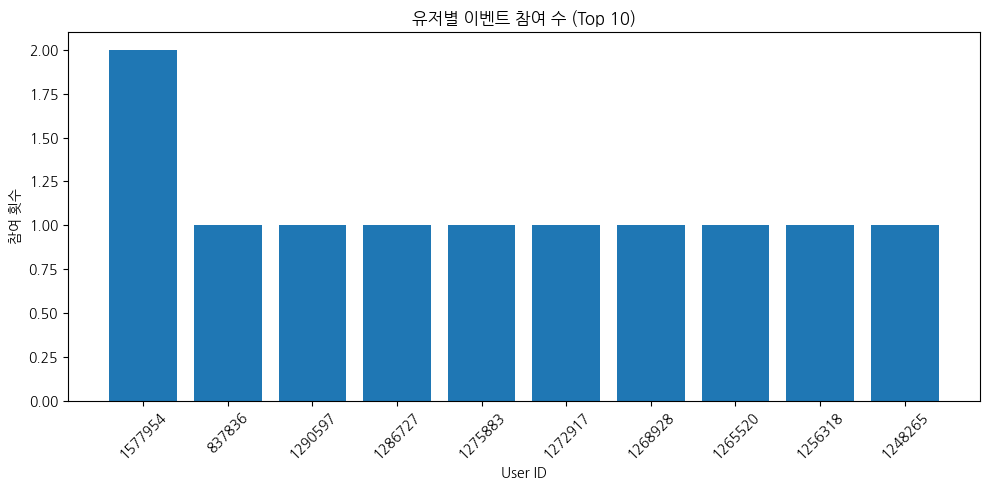

In [76]:
user_participation = (
    event_info_df
    .groupby("user_id", as_index=False)
    .size()
    .rename(columns={"size": "participation_count"})
    .sort_values("participation_count", ascending=False)
)
print("=== 유저별 이벤트 참여 Top 10 ===")
print(user_participation.head(10))

plt.figure(figsize=(10, 5))
plt.bar(user_participation["user_id"].astype(str).head(10),
        user_participation["participation_count"].head(10))
plt.title("유저별 이벤트 참여 수 (Top 10)")
plt.xlabel("User ID")
plt.ylabel("참여 횟수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
user_df[user_df["user_id"].eq(1577954)]

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,id_attendance,attendance_date_list,grade,class_num,school_id,address,student_count,school_type
671688,1577954,0,0,F,99212,"[838785, 982531, 882567, 879496, 838541, 83649...",1,2023-07-09 18:07:04.204081,[],[],N,71,21,1801,11,1.0,357483.0,"[""2023-10-20""]",1.0,1.0,1.0,None,NaN,None


3. 이벤트 참여한 유저들은 투표/포인트 사용량이 높은가

=== 유저 행동 지표 상관계수 ===
                              event_participation_count  total_point_used  \
event_participation_count                      1.000000         -0.237783   
total_point_used                              -0.237783          1.000000   
question_participation_count                  -0.252445          0.653303   

                              question_participation_count  
event_participation_count                        -0.252445  
total_point_used                                  0.653303  
question_participation_count                      1.000000  


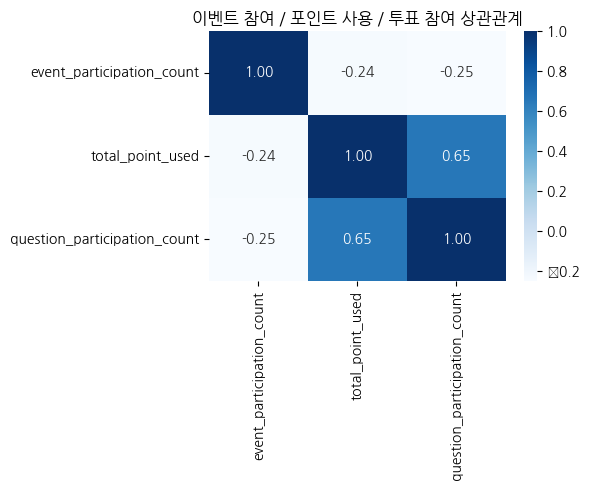

In [92]:
event_summary = event_info_df.groupby("user_id").size().reset_index(name="event_participation_count")

vote_point_summary = vote_point_df.groupby("user_id_point")["delta_point"].sum().reset_index()
vote_point_summary.rename(columns={"user_id_point": "user_id", "delta_point": "total_point_used"}, inplace=True)
vote_point_summary["total_point_used"] = abs(vote_point_summary["total_point_used"])

question_summary = question_df.groupby("user_id").size().reset_index(name="question_participation_count")

user_behavior_df = (
    event_summary
    .merge(vote_point_summary, on="user_id", how="outer")
    .merge(question_summary, on="user_id", how="outer")
    .fillna(0)
)

corr_matrix = user_behavior_df[["event_participation_count", "total_point_used", "question_participation_count"]].corr()

print("=== 유저 행동 지표 상관계수 ===")
print(corr_matrix)

# 6. 시각화 (Heatmap)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("이벤트 참여 / 포인트 사용 / 투표 참여 상관관계")
plt.tight_layout()
plt.show()

user_df

1. 친구가 많을수록 선택을 많이 받는가

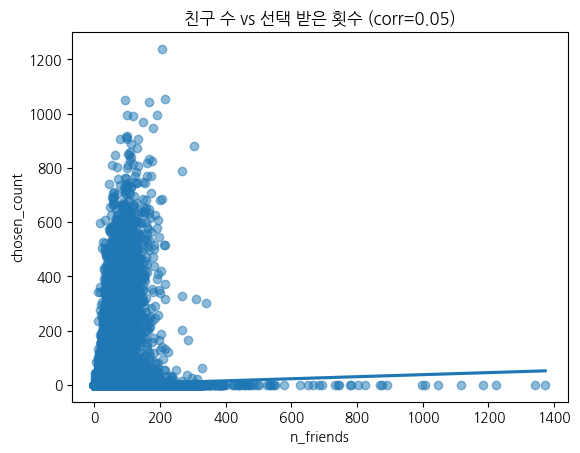

In [110]:
user_df["friend_id_list"] = user_df["friend_id_list"].apply(json.loads)
user_df["n_friends"] = user_df["friend_id_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)
user_df["attendance_date_list"] = user_df["attendance_date_list"].apply(
    lambda x: json.loads(x) if isinstance(x, str) else []
)
user_df["n_attendance"] = user_df["attendance_date_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)


chosen_count = vote_point_df.groupby("chosen_user_id").size().reset_index(name="chosen_count")
vote_count = vote_point_df.groupby("user_id").size().reset_index(name="vote_count")

updated_user_df = (
    user_df
    .merge(chosen_count, left_on="user_id", right_on="chosen_user_id", how="left")
    .merge(vote_count, left_on="user_id", right_on="user_id", how="left")
)
updated_user_df[["chosen_count", "vote_count"]] = updated_user_df[["chosen_count", "vote_count"]].fillna(0)

corr_chosen = updated_user_df["n_friends"].corr(updated_user_df["chosen_count"])
sns.regplot(data=updated_user_df, x="n_friends", y="chosen_count", scatter_kws={'alpha':0.5})
plt.title(f"친구 수 vs 선택 받은 횟수 (corr={corr_chosen:.2f})")
plt.show()

2. 친구가 많을수록 투표 많이 하는가

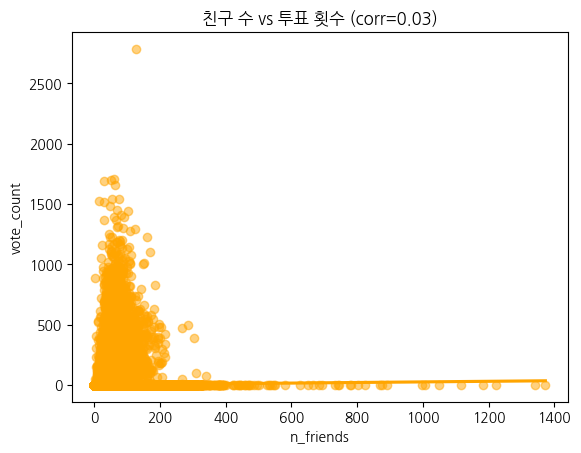

In [112]:
corr_vote = updated_user_df["n_friends"].corr(updated_user_df["vote_count"])
sns.regplot(data=updated_user_df, x="n_friends", y="vote_count", scatter_kws={'alpha':0.5}, color="orange")
plt.title(f"친구 수 vs 투표 횟수 (corr={corr_vote:.2f})")
plt.show()

3. 출석일수가 높을수록 포인트 보유량이 많은가

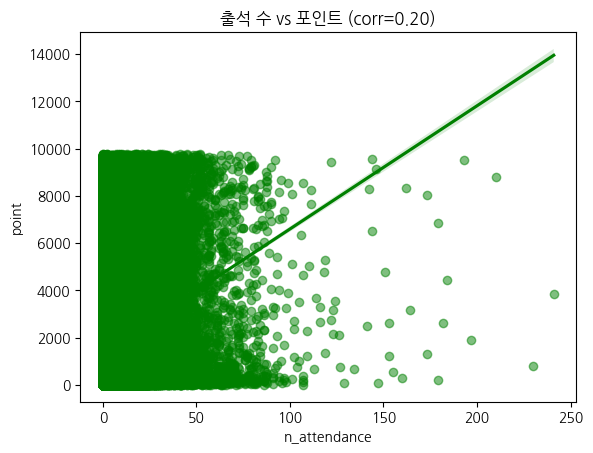

In [115]:
updated_user_df = updated_user_df[updated_user_df["point"] < updated_user_df["point"].quantile(0.99)]

corr_point = updated_user_df["n_attendance"].corr(updated_user_df["point"])
sns.regplot(data=updated_user_df, x="n_attendance", y="point", scatter_kws={'alpha':0.5}, color="green")
plt.title(f"출석 수 vs 포인트 (corr={corr_point:.2f})")
plt.show()

paymenthistory_df

1. 어느 유저가 구매를 많이 했는가

In [131]:
user_purchase = (
    paymenthistory_df.groupby("user_id").size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)
print("구매 많이 한 유저 TOP 10")
print(user_purchase.head(10))

구매 많이 한 유저 TOP 10
       user_id  purchase_count
55604  1527451              60
27744  1246471              51
17651  1141603              35
23067  1204373              34
17740  1142775              30
19921  1170271              27
14443  1099530              27
48412  1455819              25
38704  1358363              25
3839    925538              24


2. 어떤 상품이 많이 구매되었는가

In [121]:
product_purchase = (
    paymenthistory_df.groupby("productId").size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)
print("상품별 구매 건수")
print(product_purchase)


상품별 구매 건수
    productId  purchase_count
3   heart.777           57873
0  heart.1000           19309
1   heart.200           15822
2  heart.4000            2136


3. 언제/어느 시간대에 구매가 많이 이루어졌는가

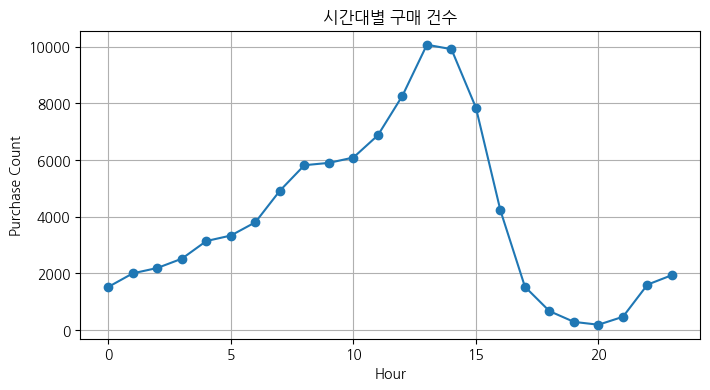

In [124]:
paymenthistory_df["created_at"] = pd.to_datetime(paymenthistory_df["created_at"])
paymenthistory_df["hour"] = paymenthistory_df["created_at"].dt.hour
paymenthistory_df["year_month"] = paymenthistory_df["created_at"].dt.to_period("M").astype(str)

hourly_purchase = paymenthistory_df.groupby("hour").size().reset_index(name="purchase_count")
monthly_purchase = paymenthistory_df.groupby("year_month").size().reset_index(name="purchase_count")

plt.figure(figsize=(8,4))
plt.plot(hourly_purchase["hour"], hourly_purchase["purchase_count"], marker="o")
plt.title("시간대별 구매 건수")
plt.xlabel("Hour")
plt.ylabel("Purchase Count")
plt.grid(True)
plt.show()


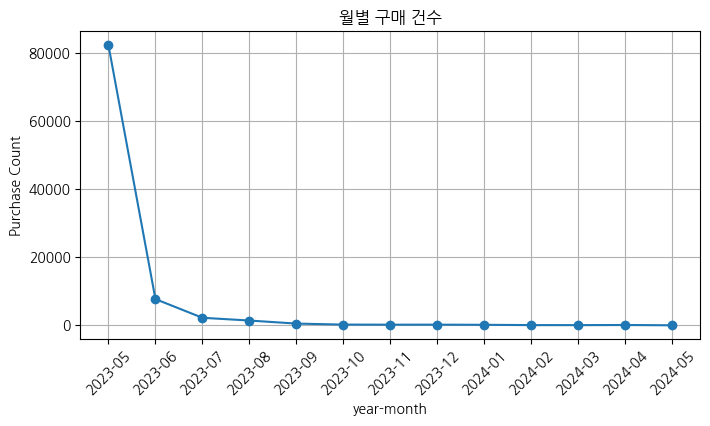

In [127]:
plt.figure(figsize=(8,4))
plt.plot(monthly_purchase["year_month"], monthly_purchase["purchase_count"], marker="o")
plt.title("월별 구매 건수")
plt.xlabel("year-month")
plt.ylabel("Purchase Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

4. 상품 구매를 많이 한 유저가 포인트 사용량이 많은가

구매 횟수 vs 선택받은 횟수 상관계수: -0.00


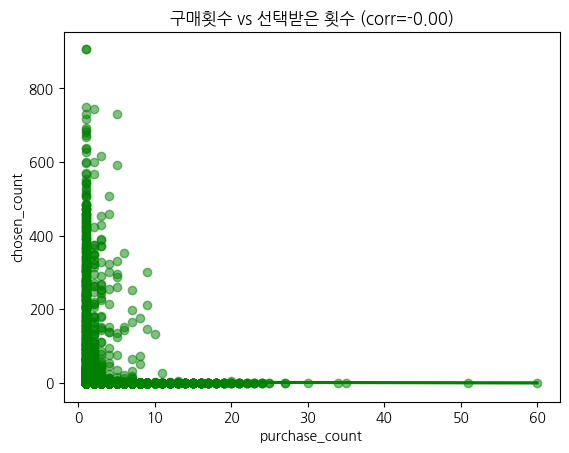

In [141]:
chosen_count = vote_point_df.groupby("chosen_user_id").size().reset_index(name="chosen_count")
user_summary = user_purchase.merge(chosen_count, left_on="user_id", right_on="chosen_user_id", how="left").fillna(0)

corr_purchase_chosen = user_summary["purchase_count"].corr(user_summary["chosen_count"])
print(f"구매 횟수 vs 선택받은 횟수 상관계수: {corr_purchase_chosen:.2f}")

sns.regplot(data=user_summary, x="purchase_count", y="chosen_count", scatter_kws={'alpha':0.5}, color="green")
plt.title(f"구매횟수 vs 선택받은 횟수 (corr={corr_purchase_chosen:.2f})")
plt.show()

# 4. 주제 아이디에이션

1. 질문 카테고리화

In [12]:
questions = question_df.question_text.unique()
questions

array(['손이 가장 이쁘게 생겼을거 같은 사람은?', '대학교에서 학생회장할 것 같은 사람은?',
       '나의 자존감을 가장 많이 높여줬던 사람은?', ...,
       '할머니,  할아버지가 돼도 이 친구만큼은 연락하고 지낼 것 같아!', '개학 하자마자 인사 될것 같은 사람',
       '너에게 칭찬을 받는다면 가장 기분 좋을 것 같아! '], dtype=object)

라벨이 없음 -> Unsupervised Learning 군집화
1. 질문 -> 벡터화 (Sentence-BERT 등)
2. 클러스터링 (KMeans 등)
3. 그룹이 만들어지면 그룹마다 의미 부여

1. 전처리 없이 임베딩, 클러스터링 -> 실루엣 점수 0.17325013875961304

In [62]:
df2 = pd.DataFrame({"question": questions})
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
embeddings = embedding_model.encode(df2["question"], show_progress_bar=True)

# ===================================
# 4. KMeans 클러스터 수 자동 선택 (4~8)
# ===================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}
for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    silhouette_scores[k] = score

best_k = max(silhouette_scores, key=silhouette_scores.get)
print("실루엣 점수별 k:", silhouette_scores)
print("선택된 최적 k:", best_k)

# ===================================
# 5. 최종 KMeans로 군집
# ===================================
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(embeddings)
df2["cluster"] = labels

# ===================================
# 6. 클러스터별 샘플 출력
# ===================================
for c in sorted(df2["cluster"].unique()):
    sample = df2[df2["cluster"] == c]["question"].sample(min(5, len(df2[df2["cluster"] == c])), random_state=42)
    print(f"\n=== Cluster {c} 샘플 ===")
    print(sample.to_string(index=False))

# ===================================
# 7. 최종 실루엣 점수
# ===================================
final_score = silhouette_score(embeddings, labels)
print("\n최종 Silhouette Score:", final_score)

Batches: 100%|██████████| 122/122 [06:48<00:00,  3.35s/it]


실루엣 점수별 k: {4: 0.17325013875961304, 5: 0.15587805211544037, 6: 0.11386987566947937, 7: 0.116774782538414, 8: 0.09419915825128555}
선택된 최적 k: 4

=== Cluster 0 샘플 ===
             눈빛이 살아있는 친구는?
          노래취향이 가장 궁금한 친구?
   얼굴을 잘 구길 수 있을 것 같은 사람은?
            가장 기억에 남는 친구는?
강아지가 된다면 가장 예쁨받을 것 같은 친구는?

=== Cluster 1 샘플 ===
네일아트가 가장 자주 바뀌는 사람은?
놀래키는 것을 가장 좋아하는 사람은?
   옷 잘 골라줄 것 같은 사람은?
   가장 꿈이 클 것 같은 사람은?
   쉬는시간마다 뛰어다니는 사람은?

=== Cluster 2 샘플 ===
별의 별 노래까지 다 알것 같은 사람
    솔직히 너랑 사귀는 상상해봤어
      거울 제일 많이 보는 사람
         길치일 것 같은 사람
   주현영 잘 따라할 것 같은 사람

=== Cluster 3 샘플 ===
       목욕탕 부끄럼없이 같이 갈수 있는 사람
 올블랙 패션이 제일 잘 어울릴 것 같은 사람은 ?
              코딩 잘할 것 같은 사람은
살짝설렜어 노래를 부르면서 프로포즈 할 것 같은사람
         디엠을 가장 오랫동안 안 보는 사람

최종 Silhouette Score: 0.17325013875961304


In [105]:
df2.cluster.value_counts()

cluster
1    1874
0     885
3     651
2     493
Name: count, dtype: int64

질문 전처리 필요?
1. 반복되는 패턴 -> 의미 차별성을 낮춤
2. 핵심 키워드 강조 
3. 불필요한 조사, 접속사 제거

In [ ]:
# import re
# import numpy as np
# import pandas as pd
# from kiwipiepy import Kiwi
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# from sentence_transformers import SentenceTransformer

# # ===================================
# # 1. 질문 리스트 (questions 사용)
# # ===================================
# df = pd.DataFrame({"question": questions})

# # ===================================
# # 2. Kiwi 기반 전처리
# # ===================================
# kiwi = Kiwi()
# STOPWORDS = {
#     "같", "같다", "같이", "듯", "제일", "가장", "뭐", "여기", "너", "얘는", "애",
#     "항상", "되게", "정말", "진짜", "좀", "제법", "엄청", "꽤"
# }
# REMOVE_VERBS = {"하다", "싶다", "주다", "있다", "이다", "되다"}
# REMOVE_NOUNS = {"사람", "친구", "누구", "이", "그", "저"}
# CUSTOM_STOPWORDS = {
#     "보다", "가다", "좋다", "어울리다", "먹다",
#     "많다", "많이", "좋아하다", "받다", "먼저",
#     "학교", "놀다", "지다", "쓰다", "알다",
#     "예쁘다", "귀엽다", "잘생기다", "이쁘다"  # 감탄사류 제거
# }

# # -------------------------------
# # 2. simplify_tokens (명사 중심)
# # -------------------------------
# def simplify_tokens(tokens):
#     result = []
#     for t in tokens:
#         if t.tag.startswith(("E", "J", "SF")):
#             continue
#         lemma = t.lemma if t.lemma else t.form
#         if lemma in STOPWORDS or lemma in REMOVE_VERBS or lemma in REMOVE_NOUNS or lemma in CUSTOM_STOPWORDS:
#             continue
#         # 명사/동사만 남기기 (외모/성격/능력/연애/라이프스타일 구분 단어)
#         if t.tag.startswith("N") or t.tag.startswith("V"):
#             result.append(lemma)
#     return result

# def extract_keywords_kiwi(text):
#     text = text.lower()
#     text = re.sub(r"[?]", "", text)
#     text = re.sub(r"(사람은|사람|친구는|친구)$", "", text)
#     text = re.sub(r"(은|는|이|가|을|를|와|과|도|만|까지|라도)$", "", text)
#     tokens = kiwi.analyze(text, top_n=1)[0][0]
#     simplified = simplify_tokens(tokens)
#     return " ".join(simplified)

# df["processed"] = df["question"].apply(extract_keywords_kiwi)

# # ===================================
# # 3. 임베딩
# # ===================================
# embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
# embeddings = embedding_model.encode(df["processed"], show_progress_bar=True)

Batches: 100%|██████████| 122/122 [03:08<00:00,  1.55s/it]


2. 형태소 분석 + 불용어 제거 등의 전처리 후 임베딩 + 클러스터링 -> 0.1276247799396515
- 실루엣 점수 오히려 낮아짐
- 전처리 하지 않겠음! 왜? sentence-transformer는 문장 의미 임베딩에 특화되어 있어서 전처리 XXX

3. 카테고리별 키워드를 정의해 임베딩하고 유사도를 계산해서 가장 유사한 카테고리에 각 할당

In [13]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 1. 데이터 불러오기
df = pd.DataFrame({"question": questions})

# 2. 카테고리 정의 및 임베딩
categories = {
    "외모": ["예쁜 외모를 가진 사람", "귀여운 스타일의 사람", "패션 센스가 좋은 사람"],    
    "성격": ["성격이 좋은 사람", "자신감 있는 사람", "다정하고 배려심 있는 사람"],
    "능력": ["공부를 잘하는 사람", "집중력이 높은 사람", "문제를 잘 해결하는 사람", "아이큐가 높은 사람"],
    "연애": ["연애를 잘하는 사람", "감정을 잘 표현하는 사람", "스킨십이 자연스러운 사람"],
    "취미": ["요리를 잘하는 사람", "춤이나 노래를 잘하는 사람", "공연을 즐기는 사람"]
}
category_texts = [" ".join(words) for words in categories.values()]
category_names = list(categories.keys())

embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
category_embeddings = embedding_model.encode(category_texts)

# 3. 질문 임베딩 및 카테고리 할당
questions = df["question"].tolist()
question_embeddings = embedding_model.encode(questions, show_progress_bar=True)

similarities = cosine_similarity(question_embeddings, category_embeddings)
assigned_categories = [category_names[np.argmax(row)] for row in similarities]
df["category_nlp"] = assigned_categories

# 4. 결과 출력
print("\n카테고리 분포:")
print(df["category_nlp"].value_counts())

# 샘플 출력
for c in sorted(df["category_nlp"].unique()):
    sample = df[df["category_nlp"] == c]["question"].sample(min(5, len(df[df["category_nlp"] == c])), random_state=42)
    print(f"\n=== Cluster {c} 샘플 ===")
    print(sample.to_string(index=False))


Batches: 100%|██████████| 122/122 [02:46<00:00,  1.36s/it]


카테고리 분포:
category_nlp
성격    1060
취미     815
외모     744
연애     712
능력     572
Name: count, dtype: int64

=== Cluster 능력 샘플 ===
일 나중에 미루다가 결국엔 못할 것 같은 사람
          의사가 될 것 같은 사람은?
      볼펜을 가장 빨리 쓸 것 같은 사람
      맞춤법 가장 잘 지킬 것 같은 사람
          잡기술이 가장 많은 사람은?

=== Cluster 성격 샘플 ===
       화장 안할 것 같은 친구
    뭘해도 긍정적일 것 같은 사람
        여기서 제일 멋진 친구
내 친구한테 소개 시켜주고 싶은 사람
     좋고 싫음이 분명한 사람은?

=== Cluster 연애 샘플 ===
              입에서 향기가 날 것 같은 사람
              사랑에 빨리 빠질 것 같은 사람
         왜 애인이 안 생기는지 모르겠는 친구는?
                 돌직구일 것 같은 사람은?
자신과 가장 잘 어울리는 사람과 결혼할 것 같은 사람은?

=== Cluster 외모 샘플 ===
 얘가 결혼하자 하면 고민좀 해볼 수 있다!
       가장 빈티지와 어울리는 사람은?
비오는 날 꼭 부츠를 신을 것 같은 사람은?
  같이 산책하면서 이야기하고 싶은 사람은?
  한복이 가장 잘 어울릴 것 같은 사람은?

=== Cluster 취미 샘플 ===
탕수육 찍먹파일 것 같은 사람은?
   가장 운동을 잘하는 사람은?
      같이 춤추고 싶은 사람
      업어주고 싶은 사람은?
 목소리가 가장 허스키한 사람은?


In [14]:
# 유사도 계산 및 최대 유사도
df["max_similarity"] = similarities.max(axis=1)  
for idx, name in enumerate(category_names):
    df[f"sim_{name}"] = similarities[:, idx]

result_df = df[["question", "category_nlp", "max_similarity"] + [f"sim_{c}" for c in category_names]]

In [15]:
result_df.loc[result_df["max_similarity"] < 0.35, "category_nlp"] = "기타"

In [16]:
result_df.value_counts("category_nlp")


category_nlp
성격    975
외모    682
취미    637
연애    588
기타    537
능력    484
Name: count, dtype: int64

In [17]:
result_df[result_df["question"].str.contains("휴대폰 배터리")].head(10)

,question,category_nlp,max_similarity,sim_외모,sim_성격,sim_능력,sim_연애,sim_취미
3891,휴대폰 배터리를 절대 충전 안 할 것 같은 사람,기타,0.144465,0.117491,0.128714,0.113365,0.144465,0.073775


# 5. 지표 설정

In [18]:
category_df = result_df.copy()
category_df.head(1)

,question,category_nlp,max_similarity,sim_외모,sim_성격,sim_능력,sim_연애,sim_취미
0,손이 가장 이쁘게 생겼을거 같은 사람은?,외모,0.650172,0.650172,0.504552,0.349466,0.477521,0.517959


In [19]:
vote_point_df.head(1)

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times,user_question_record_id,point_owner,delta_points
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,771777.0,849436,[9]


In [20]:
question_df.head(1)

,id_set,question_piece_id,opening_time,status,created_at_set,user_id,is_voted,is_skipped,created_at_piece,question_id,question_text
0,99817,998458,2023-04-28 12:27:22,F,2023-04-28 12:27:23,849436,1.0,0.0,2023-04-28 12:27:22,252.0,손이 가장 이쁘게 생겼을거 같은 사람은?


In [ ]:
base_df = question_df.merge(
    category_df[["question", "category_nlp"]],
    left_on="question_text", right_on="question", how="left"
)
base_df["is_skipped"] = base_df["is_skipped"].fillna(0).astype(int)
base_df["is_voted"] = base_df["is_voted"].fillna(0).astype(int)

# 노출/스킵/투표 집계
skip_exposed_df = base_df.groupby(
    ["question_id", "question_text", "category_nlp"]
).agg(
    exposed_impressions=("user_id", "size"),    
    skipped_users=("is_skipped", "sum"),
    voted_users=("is_voted", "sum"),
).reset_index()

# 포인트 집계
qp_df = base_df.merge(
    vote_point_df,
    on=["question_id", "user_id", "question_piece_id"],
    how="left",
    suffixes=("", "_vote")
)

qp_df["delta_points"] = qp_df["delta_points"].apply(
    lambda x: x if isinstance(x, np.ndarray) else []
)

def _sum_used(pts):  return sum(p for p in pts if p < 0)
def _sum_gain(pts):  return sum(p for p in pts if p > 0)
def _cnt_used(pts):  return sum(1 for p in pts if p < 0)
def _cnt_gain(pts):  return sum(1 for p in pts if p > 0)
def _avg_used(pts):
    used = [p for p in pts if p < 0]
    return (sum(used) / len(used)) if used else 0.0

qp_df["point_used_total"] = qp_df["delta_points"].apply(_sum_used)
qp_df["point_gain_total"] = qp_df["delta_points"].apply(_sum_gain)
qp_df["point_used_count"] = qp_df["delta_points"].apply(_cnt_used)
qp_df["point_gain_count"] = qp_df["delta_points"].apply(_cnt_gain)
qp_df["point_used_avg"]   = qp_df["delta_points"].apply(_avg_used)

agg_votes_points = qp_df.groupby(
    ["question_id", "question_text", "category_nlp"]
).agg(
    vote_count=("is_voted", "sum"),
    point_used_count=("point_used_count", "sum"),
    point_used_total=("point_used_total", "sum"),
    point_used_avg=("point_used_avg", "mean"),
    point_gain_count=("point_gain_count", "sum"),
    point_gain_total=("point_gain_total", "sum"),
).reset_index()

# 메인 집계 결합
question_metrics_df = agg_votes_points.merge(
    skip_exposed_df,
    on=["question_id", "question_text", "category_nlp"],
    how="left"
)

question_metrics_df["vote_rate"]   = question_metrics_df["voted_users"] / question_metrics_df["exposed_impressions"]
question_metrics_df["skip_rate"]   = question_metrics_df["skipped_users"] / question_metrics_df["exposed_impressions"]
question_metrics_df["point_used_rate"] = question_metrics_df["point_used_count"] / question_metrics_df["exposed_impressions"]
question_metrics_df["avg_votes_per_impression"] = question_metrics_df["voted_users"] / question_metrics_df["exposed_impressions"]

cols_keep = [
    "question_id","question_text","category_nlp","exposed_impressions",
    "voted_users","skipped_users",
    "vote_count",
    "point_used_count","point_used_total","point_used_avg",
    "point_gain_count","point_gain_total",
    "vote_rate","skip_rate","point_used_rate","avg_votes_per_impression"
]
question_metrics_df = question_metrics_df[cols_keep]

In [91]:
# DuckDB에 데이터프레임 저장
mem_con.execute("""
    COPY question_metrics_df TO 'gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/final_question_df.parquet' (FORMAT PARQUET);
""")

# 6. 질문 데이터 추가 EDA

In [9]:
final_question_df = mem_con.execute("""
    SELECT * FROM read_parquet('gs://sprintda07-gohee-bucket/final_project/최종프로젝트_데이터(parquet)/votes/final_question_df.parquet')
""").fetchdf()

print(final_question_df.head())

   question_id                 question_text category_nlp  \
0         99.0            가장 신비한 매력이 있는 사람은?           성격   
1        100.0  "이 사람으로 한 번 살아보고 싶다" 하는 사람은?           연애   
2        101.0                     미래의 틱톡커는?           기타   
3        102.0               여기서 제일 특이한 친구는?           성격   
4        103.0               가장 지켜주고 싶은 사람은?           성격   

   exposed_impressions  voted_users  skipped_users  vote_count  \
0                 1724         1696              0        2983   
1                 1736         1701              0        2972   
2                 1851         1817              0        3159   
3                 1975         1946              0        3449   
4                 1665         1632              1        2867   

   point_used_count  point_used_total  point_used_avg  point_gain_count  \
0               124            -33170       -8.857522              2970   
1               150            -38560      -10.248032              2963   
2          

카테고리별 EDA

In [10]:
final_question_df["category_nlp"].value_counts().sort_index()

category_nlp
기타     771
능력     590
성격    1206
연애     717
외모     842
취미     818
Name: count, dtype: int64

In [35]:
no_dups_df = final_question_df.drop_duplicates(subset=["question_text"])
no_dups_df["category_nlp"].value_counts().sort_index()

category_nlp
기타    537
능력    484
성격    975
연애    588
외모    682
취미    637
Name: count, dtype: int64

In [36]:
cols = no_dups_df.columns.difference(["category_nlp", "question_text", "question_id"])
per_cat_df = no_dups_df.groupby("category_nlp")[cols].mean().sort_index().round(2).reset_index().rename(columns={"index": "category_nlp"})
per_cat_df

,category_nlp,avg_votes_per_impression,exposed_impressions,point_gain_count,point_gain_total,point_used_avg,point_used_count,point_used_rate,point_used_total,skip_rate,skipped_users,vote_count,vote_rate,voted_users
0,기타,0.84,288.01,507.91,5082.07,-5.41,25.19,0.08,-4758.88,0.0,0.31,507.70,0.84,277.41
1,능력,0.86,411.03,726.84,7265.54,-4.09,25.14,0.07,-4521.88,0.0,0.28,726.47,0.86,398.20
2,성격,0.85,345.26,610.63,6103.03,-5.98,29.74,0.08,-6005.96,0.0,0.29,610.33,0.85,333.38
3,연애,0.84,256.39,450.63,4497.60,-7.66,29.19,0.11,-6039.76,0.0,0.27,450.35,0.84,245.60
4,외모,0.86,314.36,554.06,5534.27,-5.32,29.18,0.08,-5846.76,0.0,0.29,553.83,0.86,302.91
5,취미,0.85,304.09,537.17,5363.93,-4.08,24.52,0.07,-4366.59,0.0,0.24,536.90,0.85,293.21


In [38]:
top_questions_per_cat = (
    no_dups_df
    .sort_values(["category_nlp", "voted_users"], ascending=[True, False])
    .groupby("category_nlp")
    .head(5)
)

top_questions_per_cat

,question_id,question_text,category_nlp,exposed_impressions,voted_users,skipped_users,vote_count,point_used_count,point_used_total,point_used_avg,point_gain_count,point_gain_total,vote_rate,skip_rate,point_used_rate,avg_votes_per_impression
87,186.0,vote,기타,1991,1953,3,3467,77,-13690,-3.644793,3465,34516,0.980914,0.001507,0.038674,0.980914
182,281.0,유튜버로 성공할 것 같은 사람은?,기타,1917,1890,1,3291,56,-10600,-3.089210,3290,32733,0.985915,0.000522,0.029212,0.985915
64,163.0,10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은?,기타,1914,1884,3,3259,57,-10420,-2.718658,3257,32896,0.984326,0.001567,0.029781,0.984326
92,191.0,많이 먹어도 몸무게가 그대로일 것 같은 사람은?,기타,1898,1864,0,3273,73,-13960,-3.811612,3269,32608,0.982086,0.000000,0.038462,0.982086
193,292.0,생일 선물로 기프티콘 100개 넘게 받을 것 같은 사람은?,기타,1881,1853,2,3235,63,-11850,-3.100419,3230,32275,0.985114,0.001063,0.033493,0.985114
145,244.0,대학교에서 학생회장할 것 같은 사람은?,능력,1975,1946,0,3412,56,-13020,-3.390003,3412,33764,0.985316,0.000000,0.028354,0.985316
170,269.0,어떤 모임에서도 항상 리드를 할 것 같은 사람은?,능력,1945,1915,0,3365,45,-9340,-2.648012,3362,33414,0.984576,0.000000,0.023136,0.984576
77,176.0,무서운 놀이기구를 제일 잘탈것 같은 사람은?,능력,1925,1899,0,3349,73,-10870,-3.042963,3347,33409,0.986494,0.000000,0.037922,0.986494
79,178.0,게임을 제일 잘할 것 같은 사람은?,능력,1916,1882,1,3320,106,-27520,-6.446035,3319,32872,0.982255,0.000522,0.055324,0.982255
207,306.0,나중에 알바를 할 때 가장 일을 잘 할거 같은 사람은?,능력,1911,1879,0,3273,48,-9360,-2.363086,3272,32951,0.983255,0.000000,0.025118,0.983255


In [40]:
top_questions_per_cat[["category_nlp", "question_text"]]

,category_nlp,question_text
87,기타,vote
182,기타,유튜버로 성공할 것 같은 사람은?
64,기타,10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은?
92,기타,많이 먹어도 몸무게가 그대로일 것 같은 사람은?
193,기타,생일 선물로 기프티콘 100개 넘게 받을 것 같은 사람은?
145,능력,대학교에서 학생회장할 것 같은 사람은?
170,능력,어떤 모임에서도 항상 리드를 할 것 같은 사람은?
77,능력,무서운 놀이기구를 제일 잘탈것 같은 사람은?
79,능력,게임을 제일 잘할 것 같은 사람은?
207,능력,나중에 알바를 할 때 가장 일을 잘 할거 같은 사람은?


In [42]:
top10_df = no_dups_df.sort_values(["voted_users"], ascending=[False]).head(10)
top10_df["group"] = "Top 10"
top10_df

,question_id,question_text,category_nlp,exposed_impressions,voted_users,skipped_users,vote_count,point_used_count,point_used_total,point_used_avg,point_gain_count,point_gain_total,vote_rate,skip_rate,point_used_rate,avg_votes_per_impression,group
71,170.0,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,성격,2030,1998,2,3492,56,-10410,-2.753973,3490,34629,0.984236,0.000985,0.027586,0.984236,Top 10
191,290.0,모든 사람과 잘 지낼 것 같은 사람은?,성격,2021,1987,1,3442,61,-13830,-3.446490,3435,33989,0.983177,0.000495,0.030183,0.983177,Top 10
70,169.0,축제에서 공연을 제일 잘 할거 같은 사람은?,취미,2017,1985,1,3482,77,-15840,-4.003035,3481,34594,0.984135,0.000496,0.038176,0.984135,Top 10
112,211.0,앞으로의 인생을 가장 재미있게 살것 같은 사람은?,취미,2009,1975,1,3481,56,-10500,-2.642959,3477,34672,0.983076,0.000498,0.027875,0.983076,Top 10
211,310.0,반려동물과 가장 잘 지낼거 같은 사람은?,성격,1985,1958,2,3473,74,-14860,-3.691905,3474,34965,0.986398,0.001008,0.037280,0.986398,Top 10
87,186.0,vote,기타,1991,1953,3,3467,77,-13690,-3.644793,3465,34516,0.980914,0.001507,0.038674,0.980914,Top 10
145,244.0,대학교에서 학생회장할 것 같은 사람은?,능력,1975,1946,0,3412,56,-13020,-3.390003,3412,33764,0.985316,0.000000,0.028354,0.985316,Top 10
3,102.0,여기서 제일 특이한 친구는?,성격,1975,1946,0,3449,115,-26930,-7.120472,3441,34687,0.985316,0.000000,0.058228,0.985316,Top 10
210,309.0,흰티에 청바지가 잘 어울릴것 같은 사람은?,외모,1963,1939,0,3396,126,-33050,-7.987329,3393,34126,0.987774,0.000000,0.064187,0.987774,Top 10
53,152.0,숨겨진 댄싱 머신이라고 생각하는 사람은?,취미,1956,1934,1,3419,94,-18930,-4.450257,3415,34012,0.988753,0.000511,0.048057,0.988753,Top 10


In [43]:
bot10_df = no_dups_df.sort_values(["voted_users"], ascending=[True]).head(10)
bot10_df["group"] = "Bottom 10"
bot10_df

,question_id,question_text,category_nlp,exposed_impressions,voted_users,skipped_users,vote_count,point_used_count,point_used_total,point_used_avg,point_gain_count,point_gain_total,vote_rate,skip_rate,point_used_rate,avg_votes_per_impression,group
4152,4280.0,너에게 칭찬을 받는다면 가장 기분 좋을 것 같아!,성격,2,0,0,0,0,0,0.0,0,0,0.000000,0.0,0.000000,0.000000,Bottom 10
4792,4970.0,개학 하자마자 인사 될것 같은 사람,성격,1,1,0,2,0,0,0.0,2,20,1.000000,0.0,0.000000,1.000000,Bottom 10
4180,4313.0,사달라는거 다 사줄 것 같은 사람은?,기타,1,1,0,1,0,0,0.0,1,8,1.000000,0.0,0.000000,1.000000,Bottom 10
3382,3491.0,만약에 영혼이 바뀐다면 누가 되고싶어?,기타,7,1,0,2,0,0,0.0,2,28,0.142857,0.0,0.000000,0.142857,Bottom 10
4270,4412.0,"할머니, 할아버지가 돼도 이 친구만큼은 연락하고 지낼 것 같아!",성격,5,1,0,2,0,0,0.0,2,30,0.200000,0.0,0.000000,0.200000,Bottom 10
3599,3708.0,나도 모르게 자꾸 시선이 가는사람,연애,7,3,0,4,0,0,0.0,4,39,0.428571,0.0,0.000000,0.428571,Bottom 10
4027,4136.0,내가 가장 아끼는 친구,성격,8,3,0,6,0,0,0.0,6,62,0.375000,0.0,0.000000,0.375000,Bottom 10
3299,3408.0,가장 냉정한 사람,성격,5,3,0,6,0,0,0.0,6,46,0.600000,0.0,0.000000,0.600000,Bottom 10
3751,3860.0,한번쯤 목마를 태워주고 싶은사람은?,취미,6,3,0,3,0,0,0.0,3,40,0.500000,0.0,0.000000,0.500000,Bottom 10
3737,3846.0,어렸을 때 가장 험하게 놀았을 것 같은 친구는?,성격,6,4,0,8,1,-200,-20.0,8,90,0.666667,0.0,0.166667,0.666667,Bottom 10


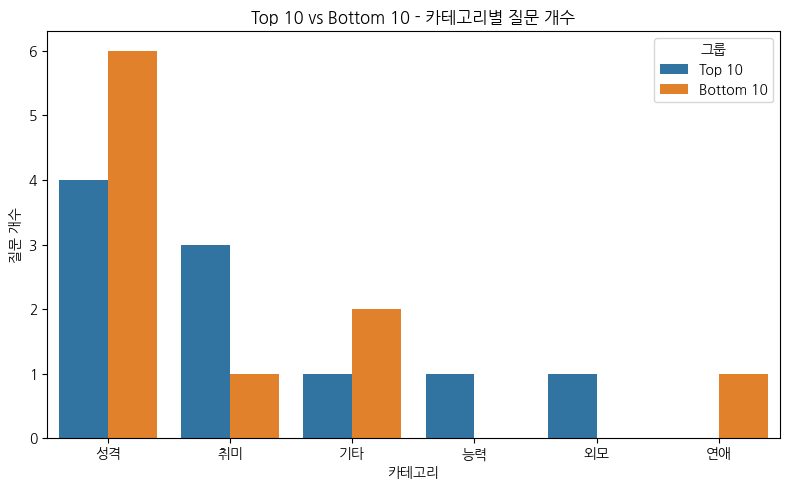

In [44]:
compare_df = pd.concat([top10_df, bot10_df], ignore_index=True)

plt.figure(figsize=(8,5))
sns.countplot(data=compare_df, x="category_nlp", hue="group",
              order=compare_df["category_nlp"].value_counts().index)
plt.title("Top 10 vs Bottom 10 - 카테고리별 질문 개수")
plt.xlabel("카테고리")
plt.ylabel("질문 개수")
plt.legend(title="그룹")
plt.tight_layout()
plt.show()

# 7. Airflow를 통해 적재된 데이터 확인

In [66]:
from google.cloud import bigquery
# (필요시) 서비스 계정 키 지정
# import os; os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "key/my-projectcodeit.json"

BQ_PROJECT = "my-projectcodeit"
BQ_DATASET = "final_project"
BQ_TABLE   = "vote_point"

bq = bigquery.Client(project=BQ_PROJECT)

# 데이터셋 위치 자동 조회 → 쿼리 위치에 넣기
ds = bq.get_dataset(f"{BQ_PROJECT}.{BQ_DATASET}")
LOCATION = ds.location  # 예: 'asia-northeast3', 'US' 등

sql = f"""
SELECT *
FROM `{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}`
"""

job = bq.query(sql, location=LOCATION)

# BigQuery Storage API가 있으면 빠르게, 없으면 일반 경로로
try:
    from google.cloud import bigquery_storage_v1
    bqs = bigquery_storage_v1.BigQueryReadClient()
    df = job.result().to_dataframe(bqstorage_client=bqs)
except Exception:
    df = job.result().to_dataframe()

print(df.head())
print("rows:", len(df))


         id status                created_at  chosen_user_id  question_id  \
0  49075339      C 2023-05-15 06:45:01+00:00         1041959          348   
1  49076106      C 2023-05-15 06:45:09+00:00         1018080          163   
2  49081039      C 2023-05-15 06:45:57+00:00         1085098          260   
3  49081065      C 2023-05-15 06:45:57+00:00         1207194          469   
4  49081218      C 2023-05-15 06:45:59+00:00         1186756          431   

   user_id  question_piece_id  has_read answer_status  \
0  1078778           62585040         0             N   
1  1063458           62833575         0             N   
2  1040367           60955277         1             N   
3  1259186           63474663         0             N   
4  1263347           63741670         1             A   

          answer_updated_at  report_count  opened_times          ds  \
0 2023-05-15 06:45:01+00:00             0             0  2023-05-15   
1 2023-05-15 06:45:09+00:00             0           

In [85]:
from google.cloud import bigquery
import datetime as dt
# (필요시) 서비스 계정 키 지정
# import os; os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "key/my-projectcodeit.json"

BQ_PROJECT = "my-projectcodeit"
BQ_DATASET = "final_project"
BQ_TABLE   = "final_question"

bq = bigquery.Client(project=BQ_PROJECT)

# 데이터셋 위치 자동 조회 → 쿼리 위치에 넣기
ds = bq.get_dataset(f"{BQ_PROJECT}.{BQ_DATASET}")
LOCATION = ds.location  # 예: 'asia-northeast3', 'US' 등

target_date = dt.date(2023, 5, 1)  # 보고 싶은 날짜

sql = f"""
SELECT *
FROM `{BQ_PROJECT}.{BQ_DATASET}.{BQ_TABLE}`
WHERE DATE(ds, 'Asia/Seoul') = @ds
"""

job = bq.query(
    sql,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ScalarQueryParameter("ds", "DATE", target_date)]
    ),
    location=LOCATION,
)

# BigQuery Storage API가 있으면 빠르게, 없으면 일반 경로로
try:
    from google.cloud import bigquery_storage_v1
    bqs = bigquery_storage_v1.BigQueryReadClient()
    df = job.result().to_dataframe(bqstorage_client=bqs)
except Exception:
    df = job.result().to_dataframe()

print(df.head())
print("rows:", len(df))


                         ds  question_id                question_text  \
0 2023-05-01 00:00:00+00:00        273.0          같이 쇼핑하면 가장 재밌는 사람은?   
1 2023-05-01 00:00:00+00:00        210.0           친구들에게 가장 인정받는 사람은?   
2 2023-05-01 00:00:00+00:00        288.0  내 자식으로 태어나면 가장 좋을 것 같은 사람은?   
3 2023-05-01 00:00:00+00:00        252.0       손이 가장 이쁘게 생겼을거 같은 사람은?   
4 2023-05-01 00:00:00+00:00        311.0             연락을 제일 잘 하는 사람은?   

  category_nlp  exposed_impressions  voted_users  skipped_users  vote_count  \
0           취미                   35           35              0          37   
1           성격                   37           37              0          38   
2           성격                   39           39              0          41   
3           외모                   42           42              0          42   
4           성격                   45           45              0          46   

   point_used_count  point_used_total  point_used_avg  point_gain_count  \
0          

In [86]:
df["category_nlp"].value_counts()

category_nlp
성격    58
능력    45
외모    42
취미    32
연애    25
기타    25
Name: count, dtype: int64